# Differentiation & Optimisation in Machine Learning

> **Topics covered in this notebook:**
> 1. Basic Differentiation — Power Rule, Sum Rule
> 2. Chain Rule
> 3. Partial Differentiation
> 4. Cost Function (MSE)
> 5. Partial Derivatives of the Cost Function w.r.t W and B
> 6. Optimisation Methods — Normal Equation vs Gradient Descent
> 7. Gradient Descent in detail — Learning Rate, Local vs Global Minima
> 8. Worked numerical example of Gradient Descent

---


In [18]:
# ── ALL IMPORTS — run this cell first ────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp        # symbolic mathematics: exact derivatives, symbolic algebra

---
## 1. Basic Differentiation — Power Rule & Sum Rule

Differentiation is a fundamental mathematical tool used extensively in machine learning to optimise models.

### Power Rule
If a function has the form `f(x) = x^n`, its derivative is:

```
f'(x) = n · x^(n-1)
```

The exponent `n` comes down as a multiplier, and the power is reduced by 1.

### Sum Rule
If two functions are added together `f(x) + g(x)`, differentiate each term separately and add the results:

```
d/dx [ f(x) + g(x) ]  =  f'(x) + g'(x)
```

### Examples

**Example 1 — derivative of `3x² + 5x⁸`:**

```
d/dx (3x²)  =  2 · 3 · x^(2-1)  =  6x
d/dx (5x⁸)  =  8 · 5 · x^(8-1)  =  40x⁷

Result:  6x + 40x⁷
```


In [19]:
x = sp.Symbol('x')  # declare x as a symbolic variable (not a number)

# ── Power Rule: d/dx (x^n) = n · x^(n-1) ────────────────────
f1 = sp.Add(sp.Integer(3) * x**2, sp.Integer(5) * x**8)   # function from Example 1

# sp.diff(function, variable) → computes the derivative symbolically
df1 = sp.diff(f1, x)   # applies Power Rule + Sum Rule automatically

print("Function  : f(x) =", f1)
print("Derivative: f'(x) =", df1)
# Expected:  6x + 40x^7

# ── verify step by step ──────────────────────────────────────
term1 = sp.Integer(3) * x**2
term2 = sp.Integer(5) * x**8

d_term1 = sp.diff(term1, x)   # d/dx (3x²) = 6x
d_term2 = sp.diff(term2, x)   # d/dx (5x⁸) = 40x⁷

sum_terms = sp.Add(d_term1, d_term2)

print(f"\nd/dx (3x²) = {d_term1}")   # 6x
print(f"d/dx (5x⁸) = {d_term2}")   # 40x⁷
print(f"Sum        = {sum_terms}")  # 6x + 40x⁷


Function  : f(x) = 5*x**8 + 3*x**2
Derivative: f'(x) = 40*x**7 + 6*x

d/dx (3x²) = 6*x
d/dx (5x⁸) = 40*x**7
Sum        = 40*x**7 + 6*x


---
## 2. Chain Rule

The Chain Rule is used to differentiate **composite functions** — functions where an expression is raised to a power.

### Rule
If `u` is an expression in `x` and the function has the form `f = u^n`, then:

```
f'  =  n · u^(n-1) · u'
         ↑             ↑
   power comes down   derivative of the inner expression u
```

### Examples

**Example 1 — derivative of `(5x − 3)²`:**
```
n = 2,   u = (5x − 3),   u' = 5

f' = 2 · (5x − 3)^(2-1) · 5  =  10(5x − 3)
```

**Example 2 — derivative of `(3x² + 8x + 4)⁸`:**
```
n = 8,   u = (3x² + 8x + 4)
u' = 6x + 8    ← derivative of inner expression (3x²→6x, 8x→8, 4→0)

f' = 8 · (3x² + 8x + 4)⁷ · (6x + 8)
```


In [20]:
# ══════════════════════════════════════════════════════════════
#  PARAMETERS — change these numbers to try different functions
# ══════════════════════════════════════════════════════════════

# Example 1: f(x) = (a·x − b)^n
a1 = 5    # coefficient of x (in the inner expression)

#So the Coefficient is the number that controls the intensity of the effect of
# x. For example, if a is large, then the function will grow faster as x increases. If a is small, then the function will grow slower as x increases.

b1 = 3    # constant term (subtracted)


n1 = 2    # power (exponent)

# Example 2: f(x) = (a·x² + b·x + c)^n
a2 = 3    # coefficient of x²
b2 = 8    # coefficient of x
c2 = 4    # constant term
n2 = 8    # power (exponent)


---

## توضیح گام‌به‌گام کد — قانون زنجیره‌ای (Chain Rule | Kettenregel)

---

### 1️⃣ ساختن عبارت داخلی (Inner Expression)

```python
u2 = sp.Add(sp.Mul(a2_s, sp.Pow(x, 2)), sp.Mul(b2_s, x), c2_s)
```

این فقط روش رسمی SymPy برای نوشتن است:

$$u(x) = ax^2 + bx + c$$

در اینجا $u(x)$ **تابع داخلی** (Inner function | innere Funktion) یعنی تابع داخل پرانتز است.

---

### 2️⃣ ساختن تابع اصلی (Outer Function)

```python
f3 = sp.Pow(u2, n2_s)
```

یعنی:

$$f(x) = \bigl(ax^2 + bx + c\bigr)^n$$

در اینجا $f(x)$ **تابع خارجی** (Outer function | äußere Funktion) است.

---

### 3️⃣ گرفتن مشتق

```python
df3 = sp.diff(f3, x)
```

اینجا SymPy خودش **قانون زنجیره‌ای** را اعمال می‌کند:

$$\frac{d}{dx}\bigl[u(x)^n\bigr] = n \cdot u(x)^{n-1} \cdot u'(x)$$

پس باید اول مشتق داخلی را حساب کنیم.

---

### 4️⃣ مشتق داخلی

$$u(x) = ax^2 + bx + c$$

$$u'(x) = 2ax + b$$

چون:

| جمله | مشتق |
|------|------|
| $ax^2$ | $2ax$ |
| $bx$ | $b$ |
| $c$ | $0$ |

---

### 5️⃣ نتیجه نهایی مشتق

پس کل مشتق می‌شود:

$$f'(x) = n \cdot \bigl(ax^2 + bx + c\bigr)^{n-1} \cdot (2ax + b)$$

---

### 6️⃣ چرا `factor` استفاده شده؟

```python
df3_factored = sp.factor(df3)
```

گاهی SymPy نتیجه را باز شده (expanded) می‌دهد.
`factor` آن را فاکتور می‌گیرد تا ساختار قانون زنجیره‌ای واضح دیده شود، یعنی دقیقاً این شکل:

$$f'(x) = n \cdot \bigl(ax^2 + bx + c\bigr)^{n-1} \cdot (2ax + b)$$

---

### 7️⃣ چرا این برای Machine Learning مهم است؟

در ML ما داریم:

$$\text{Loss}(\theta) = g(\theta)^n$$

برای **Gradient Descent (Gradientenabstieg)** باید مشتق بگیریم.
این کد نشان می‌دهد که SymPy خودش قانون زنجیره‌ای را درست اعمال می‌کند و مشتق همیشه این ساختار دارد:

$$\text{توان} \times \text{توان کم‌شده} \times \text{مشتق داخلی}$$

---

### 🔎 خلاصه خیلی ساده

| گام | کار |
|-----|-----|
| 1 | یک چندجمله‌ای درجه دو $u(x) = ax^2 + bx + c$ می‌سازیم |
| 2 | آن را به توان $n$ می‌رسانیم: $f(x) = u(x)^n$ |
| 3 | مشتق می‌گیریم — SymPy قانون زنجیر را اعمال می‌کند |
| 4 | نتیجه را با `factor` فاکتور می‌کنیم تا ساختار واضح شود |


$$
b \quad \text{(Constant term | Konstante)}
$$

The value of **b** changes the point where the expression inside the parentheses becomes zero:

$$
ax - b = 0 \Rightarrow x = \frac{b}{a}
$$

This means that **b determines where the "center" or transition point of the function is located**.

### Practical effect:

The parameter **b** shifts the graph along the **x-axis**.

In simple terms:
It moves the point where the function changes behavior (or crosses zero) forward or backward.


---

## 1) مقدار ثابت (Constant term | Konstante) چه نقشی دارد؟

---

### مثال ۱: $f(x) = (ax - b)^n$

**$b$ — (Constant term | Konstante) — جابجا کردنِ ورودی (shift)**

$b$ باعث می‌شود نقطه‌ای که داخل پرانتز صفر می‌شود عوض شود:

$$ax - b = 0 \Rightarrow x = \frac{b}{a}$$

یعنی $b$ تعیین می‌کند **"مرکز / محلِ تغییر رفتار"** تابع کجاست.

> **اثر عملی:** $b$ نمودار را در راستای $x$ جابجا می‌کند —
> به زبان ساده: نقطه‌ی عبور/تغییر را **جلو یا عقب** می‌بَرد.

---

### مثال ۲: $f(x) = (ax^2 + bx + c)^n$

**$c$ — (Constant term | Konstante) — بالا/پایین بردنِ مقدارِ کل تابع**

وقتی $x = 0$:

$$f(0) = (c)^n$$

پس $c$ **سطح کلی خروجی** را بالا/پایین می‌برد و پایه‌ی تابع را تغییر می‌دهد.

---

## 2) توان (Exponent / Power | Exponent / Potenz) چه نقشی دارد؟

**$n$ — (Exponent / Power | Exponent / Potenz) — شدتِ غیرخطی بودن و تندیِ رشد**

---

### (الف) شکل و رشد تابع

| توان | رفتار |
|------|-------|
| $n = 1$ | تابع ملایم‌تر / خطی‌تر است |
| $n = 2, 3, \ldots$ | خروجی خیلی سریع‌تر بزرگ می‌شود (رشد تندتر) |

**مثال عددی** — فرض کنیم مقدار داخل پرانتز $= 2$:

$$2^1 = 2, \quad 2^2 = 4, \quad 2^3 = 8, \quad 2^8 = 256$$

> پس **توان بزرگ ⇒ خروجی‌ها خیلی بزرگ‌تر می‌شوند.**

---

### (ب) اثر روی گرادیان و یادگیری (مهم در ML)

در گرادیان‌دسنت، مهم است که مشتق چقدر بزرگ شود. اگر:

$$f(x) = g(x)^n$$

آنگاه (قانون زنجیر):

$$f'(x) = n \cdot g(x)^{n-1} \cdot g'(x)$$

**نتایج بسیار مهم:**

| شرط | نتیجه | نام پدیده |
|-----|-------|-----------|
| $\|g(x)\| > 1$ و $n$ بزرگ | گرادیان **خیلی بزرگ** می‌شود | **Exploding gradients** — گرادیان انفجاری |
| $\|g(x)\| < 1$ و $n$ بزرگ | $g(x)^{n-1}$ خیلی کوچک ⇒ گرادیان **محو** می‌شود | **Vanishing gradients** — گرادیان محو شونده |

> **نتیجه‌گیری:** توان $n$ روی **سرعت و پایداری یادگیری** اثر مستقیم دارد.


In [21]:
# ══════════════════════════════════════════════════════════════
#  Chain Rule:  d/dx [ u(x)^n ]  =  n · u^(n-1) · u'(x)
# ══════════════════════════════════════════════════════════════

x = sp.Symbol('x')   # symbolic variable (That is, x is not a number, but a mathematical variable for calculating the derivative.)

# convert Python ints to SymPy Integers for type-safe symbolic ops
a1_s, b1_s, n1_s = sp.Integer(a1), sp.Integer(b1), sp.Integer(n1)
a2_s, b2_s, c2_s, n2_s = sp.Integer(a2), sp.Integer(b2), sp.Integer(c2), sp.Integer(n2)

# ── Example 1 ─────────────────────────────────────────────────
u1 = sp.Add(sp.Mul(a1_s, x), sp.Mul(sp.Integer(-1), b1_s))   # inner expression
f2 = sp.Pow(u1, n1_s)
df2 = sp.diff(f2, x)          # sympy applies chain rule automatically
df2_expanded = sp.expand(df2) # expand the result to see the full expression clearly

print("── Example 1 ──────────────────────────────────────────────")
print(f"  Parameters : a={a1}, b={b1}, n={n1}") # print the parameters for clarity
print(f"  f(x)       = ({a1}x − {b1})^{n1}")    # print the function in a nice format
print(f"  f'(x)      = {df2}")                  # print the raw derivative from sympy
print(f"  f'(x) exp. = {df2_expanded}")         # print the expanded form of the derivative

du1 = sp.diff(u1, x)          # inner derivative from sympy
du1_expr = sp.sympify(du1)    # explicit Expr form (type-safe for multiplication)
manual1 = sp.Mul(n1_s, sp.Pow(u1, sp.Add(n1_s, sp.Integer(-1))), du1_expr) #    n · u^(n-1) · u'   
match1 = sp.sympify(df2).equals(sp.sympify(manual1)) # check if the manual application of the chain rule matches sympy's result
#   result = n · a · (a·x − b)^(n-1) #  since u' = a, the inner derivative is just a constant
print(f"  inner u'(x)           = {du1}   ← derivative of inner expression") # print the inner derivative to confirm it's correct (should be a)
print(f"  Manual (n·u^(n-1)·u'): {sp.factor(manual1)}") # print the manual application of the chain rule in a factored form for clarity
print(f"  Match with sp.diff?   : {match1}") #  print whether the manual application of the chain rule matches the result from sympy (should be True)

# ── Example 2 ─────────────────────────────────────────────────
u2 = sp.Add(sp.Mul(a2_s, sp.Pow(x, 2)), sp.Mul(b2_s, x), c2_s) # inner expression: a·x² + b·x + c
f3 = sp.Pow(u2, n2_s) # outer function: (a·x² + b·x + c)^n
df3 = sp.diff(f3, x) # sympy applies chain rule automatically
df3_factored = sp.factor(df3) # factor the result to see the structure clearly (should show n · (a·x² + b·x + c)^(n-1) · (2a·x + b))

print("\n── Example 2 ──────────────────────────────────────────────")
print(f"  Parameters : a={a2}, b={b2}, c={c2}, n={n2}") # print the parameters for clarity
print(f"  f(x)       = ({a2}x² + {b2}x + {c2})^{n2}")   # print the function in a nice format
print(f"  f'(x)      = {df3_factored}")

du2 = sp.diff(u2, x)                            # inner derivative from sympy
du2_expr = sp.Add(sp.Mul(sp.Integer(2), a2_s, x), b2_s)   # explicit Expr form (type-safe)
manual2 = sp.Mul(n2_s, sp.Pow(u2, sp.Add(n2_s, sp.Integer(-1))), du2_expr) #    n · u^(n-1) · u'   where u' = 2a·x + b  
match2 = sp.sympify(df3).equals(sp.sympify(manual2)) #  check if the manual application of the chain rule matches sympy's result
#   result = n · (a·x² + b·x + c)^(n-1) · (2a·x + b) #  since u' = 2a·x + b, the inner derivative is a linear function of x
print(f"\n  inner u'(x)           = {du2}   ← derivative of inner expression") # print the inner derivative to confirm it's correct (should be 2a·x + b)
print(f"  Manual (n·u^(n-1)·u'): {sp.factor(manual2)}") # print the manual application of the chain rule in a factored form for clarity
print(f"  Match with sp.diff?   : {match2}") #  print whether the manual application of the chain rule matches the result from sympy (should be True)

── Example 1 ──────────────────────────────────────────────
  Parameters : a=5, b=3, n=2
  f(x)       = (5x − 3)^2
  f'(x)      = 50*x - 30
  f'(x) exp. = 50*x - 30
  inner u'(x)           = 5   ← derivative of inner expression
  Manual (n·u^(n-1)·u'): 10*(5*x - 3)
  Match with sp.diff?   : True

── Example 2 ──────────────────────────────────────────────
  Parameters : a=3, b=8, c=4, n=8
  f(x)       = (3x² + 8x + 4)^8
  f'(x)      = 16*(x + 2)**7*(3*x + 2)**7*(3*x + 4)

  inner u'(x)           = 6*x + 8   ← derivative of inner expression
  Manual (n·u^(n-1)·u'): 16*(x + 2)**7*(3*x + 2)**7*(3*x + 4)
  Match with sp.diff?   : True


| کد          | معنی               |
| ----------- | ------------------ |
| `sp`        | کتابخانه SymPy     |
| `sp.diff()` | مشتق گرفتن         |
| SymPy       | محاسبه نمادین دقیق |


---
## 3. Partial Differentiation

Partial differentiation is used for functions with **more than one variable** (multivariate functions).

### Concept
When differentiating with respect to one variable, **treat all other variables as constants**.

**Notation:** `∂f/∂x` — "partial derivative of f with respect to x"

### Examples

**Example 1 — `f(x, y) = 3x + 5y`:**
```
∂f/∂x  =  3          (y is treated as a constant → 5y disappears)
∂f/∂y  =  5          (x is treated as a constant → 3x disappears)
```

**Example 2 — `f(x, y) = 2x² + 4y³`:**
```
∂f/∂x  =  4x
∂f/∂y  =  12y²
```

**Example 3 — `f(x, y) = 6xy + 8x²`:**
```
∂f/∂x  =  6y + 16x   (treat y as constant: d/dx(6xy)=6y, d/dx(8x²)=16x)
∂f/∂y  =  6x          (treat x as constant: d/dy(6xy)=6x, d/dy(8x²)=0)
```

**Example 4 (with Σ) — `f(x, y) = Σᵢ (x·uᵢ + y − vᵢ)²`:**
```
∂f/∂x  =  Σ 2·(x·uᵢ + y − vᵢ) · uᵢ    ← chain rule: inner derivative w.r.t x is uᵢ
∂f/∂y  =  Σ 2·(x·uᵢ + y − vᵢ) · 1     ← chain rule: inner derivative w.r.t y is 1
```
> This is exactly the form of the gradient of the MSE cost function used in linear regression.


In [22]:
# ── Partial Differentiation ───────────────────────────────────
# sp.diff(f, var) with two symbolic variables computes partial derivative
# treating all other variables as constants automatically

x, y = sp.symbols('x y')   # declare two symbolic variables

# ── Example 1: f(x,y) = 3x + 5y ─────────────────────────────
f_ex1 = 3*x + 5*y
print("── Example 1: f(x,y) = 3x + 5y ──────────────")
print(f"  ∂f/∂x = {sp.diff(f_ex1, x)}")   # 3  (5y is constant → vanishes)
print(f"  ∂f/∂y = {sp.diff(f_ex1, y)}")   # 5  (3x is constant → vanishes)

# ── Example 2: f(x,y) = 2x² + 4y³ ──────────────────────────
f_ex2 = 2*x**2 + 4*y**3
print("\n── Example 2: f(x,y) = 2x² + 4y³ ───────────")
print(f"  ∂f/∂x = {sp.diff(f_ex2, x)}")   # 4x
print(f"  ∂f/∂y = {sp.diff(f_ex2, y)}")   # 12y²

# ── Example 3: f(x,y) = 6xy + 8x² ──────────────────────────
f_ex3 = 6*x*y + 8*x**2
print("\n── Example 3: f(x,y) = 6xy + 8x² ───────────")
print(f"  ∂f/∂x = {sp.diff(f_ex3, x)}")   # 6y + 16x  (y treated as constant in 6xy)
print(f"  ∂f/∂y = {sp.diff(f_ex3, y)}")   # 6x        (8x² has no y → vanishes)

# ── Example 4 (Sigma form): f(x,y) = Σ (x·uᵢ + y − vᵢ)² ───
# We show one term symbolically (the Σ just sums over all i)
u_i, v_i = sp.symbols('u_i v_i')   # uᵢ and vᵢ are constants w.r.t. x and y
inner = (x * u_i + y - v_i)**2     # one term of the sum

# ∂/∂x of one term — chain rule: 2·(x·uᵢ+y−vᵢ) · uᵢ
d_x = sp.diff(inner, x)
# ∂/∂y of one term — chain rule: 2·(x·uᵢ+y−vᵢ) · 1
d_y = sp.diff(inner, y)

print("\n── Example 4: one term of Σ (x·uᵢ + y − vᵢ)² ────────")
print(f"  ∂(one term)/∂x = {sp.expand(d_x)}")
# = 2·uᵢ·(x·uᵢ + y − vᵢ)
print(f"  ∂(one term)/∂y = {sp.expand(d_y)}")
# = 2·(x·uᵢ + y − vᵢ)
print("\n  Full gradient (summed over all i):")
print("  ∂f/∂x = Σ 2·(x·uᵢ + y − vᵢ) · uᵢ")
print("  ∂f/∂y = Σ 2·(x·uᵢ + y − vᵢ) · 1")


── Example 1: f(x,y) = 3x + 5y ──────────────
  ∂f/∂x = 3
  ∂f/∂y = 5

── Example 2: f(x,y) = 2x² + 4y³ ───────────
  ∂f/∂x = 4*x
  ∂f/∂y = 12*y**2

── Example 3: f(x,y) = 6xy + 8x² ───────────
  ∂f/∂x = 16*x + 6*y
  ∂f/∂y = 6*x

── Example 4: one term of Σ (x·uᵢ + y − vᵢ)² ────────
  ∂(one term)/∂x = 2*u_i**2*x - 2*u_i*v_i + 2*u_i*y
  ∂(one term)/∂y = 2*u_i*x - 2*v_i + 2*y

  Full gradient (summed over all i):
  ∂f/∂x = Σ 2·(x·uᵢ + y − vᵢ) · uᵢ
  ∂f/∂y = Σ 2·(x·uᵢ + y − vᵢ) · 1


---
## 4. Cost Function (Loss Function)

The **Cost Function** `J` (also called Loss Function) measures how wrong the model's predictions are. We always want to **minimise** it.

### Inputs
| Symbol | Name | Meaning |
|--------|------|---------|
| `W` | Weights | parameters the model learns (W₀, W₁, …) |
| `B` | Bias | a fixed offset added to the prediction |

### Prediction formula (linear regression)
```
ŷᵢ  =  W₀·x₀ᵢ  +  W₁·x₁ᵢ  +  B
```
**Example:** predicting house price from area `x₀` and number of rooms `x₁`.

### MSE — Mean Squared Error cost function
```
J(W, B)  =  (1/n) · Σᵢ (ŷᵢ − yᵢ)²
```

| Symbol | Meaning |
|--------|---------|
| `ŷᵢ` | model's prediction for sample i |
| `yᵢ` | true value for sample i |
| `n` | total number of data points |

Substituting the prediction formula:
```
J(W, B)  =  (1/n) · Σᵢ (W·xᵢ + B − yᵢ)²
```


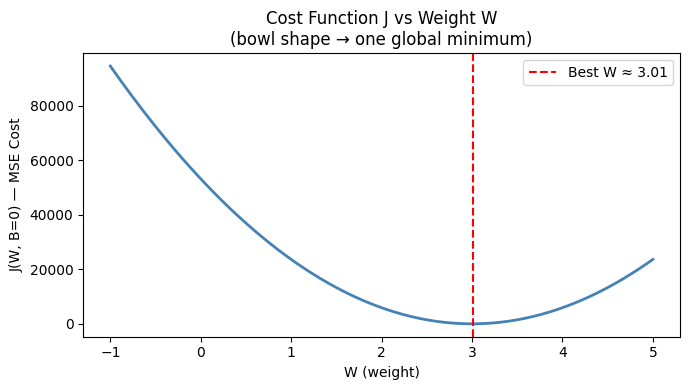

Approximate best W (B=0): 3.010
Minimum cost J          : 0.60


In [23]:
# ── Cost Function (MSE) from scratch ─────────────────────────
# J(W, B) = (1/n) · Σ (W·xᵢ + B − yᵢ)²

# Sample data: area (x) → price (y)
x_data = np.array([50, 60, 70, 80, 90, 100], dtype=float)  # feature: house area
y_data = np.array([150, 180, 210, 240, 270, 300], dtype=float)  # target: price
n = len(x_data)   # number of data points = 6

def predict(W, B, x):
    """ŷ = W·x + B  ← linear prediction"""
    return W * x + B   # W = weight, B = bias

def mse_cost(W, B, x, y):
    """
    J(W, B) = (1/n) · Σ (ŷᵢ − yᵢ)²
    MSE = Mean Squared Error
    """
    y_hat = predict(W, B, x)     # predictions for all samples at once
    errors = y_hat - y            # residuals: ŷᵢ − yᵢ  (positive or negative)
    squared_errors = errors ** 2  # squaring makes all errors positive
    return np.mean(squared_errors) # mean = divide by n

# ── evaluate cost for different W values (B fixed at 0) ──────
W_values = np.linspace(-1, 5, 200)   # try 200 values of W from -1 to 5
J_values = [mse_cost(W, 0, x_data, y_data) for W in W_values]
# list comprehension: compute J for each W, treating B=0 as fixed

plt.figure(figsize=(7, 4))
plt.plot(W_values, J_values, color="steelblue", linewidth=2)
plt.xlabel("W (weight)")
plt.ylabel("J(W, B=0) — MSE Cost")
plt.title("Cost Function J vs Weight W\n(bowl shape → one global minimum)")
plt.axvline(W_values[np.argmin(J_values)], color="red", linestyle="--",
            label=f"Best W ≈ {W_values[np.argmin(J_values)]:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

best_W = W_values[np.argmin(J_values)]
print(f"Approximate best W (B=0): {best_W:.3f}")
print(f"Minimum cost J          : {min(J_values):.2f}")


---
## 5. Partial Derivatives of the MSE Cost Function

To find the optimal W and B, we differentiate J with respect to each parameter using the **Chain Rule + Partial Differentiation**.

### Derivation

Starting from:
```
J(W, B) = (1/n) · Σ (W·xᵢ + B − yᵢ)²
```

**∂J/∂W** — treat B as constant, apply chain rule:
```
outer derivative:  2·(W·xᵢ + B − yᵢ)^(2-1)  =  2·(W·xᵢ + B − yᵢ)
inner derivative:  ∂/∂W (W·xᵢ + B − yᵢ)     =  xᵢ   (B and yᵢ are constant)

∂J/∂W  =  (2/n) · Σ (W·xᵢ + B − yᵢ) · xᵢ
```

**∂J/∂B** — treat W as constant, apply chain rule:
```
outer derivative:  2·(W·xᵢ + B − yᵢ)
inner derivative:  ∂/∂B (W·xᵢ + B − yᵢ)     =  1   (W·xᵢ and yᵢ are constant)

∂J/∂B  =  (2/n) · Σ (W·xᵢ + B − yᵢ) · 1
```

> **Important:** These are the exact gradient formulas used in **linear regression with MSE**. Other cost functions (e.g. logistic regression) produce different derivatives.


In [24]:
# ── Partial Derivatives of MSE Cost Function ─────────────────
#
# ∂J/∂W = (2/n) · Σ (W·xᵢ + B − yᵢ) · xᵢ
# ∂J/∂B = (2/n) · Σ (W·xᵢ + B − yᵢ) · 1

def grad_W(W, B, x, y):
    """
    ∂J/∂W = (2/n) · Σ (W·xᵢ + B − yᵢ) · xᵢ
    = gradient of MSE with respect to weight W
    tells us: if we increase W slightly, does J go up or down?
    """
    n = len(x)
    residuals = W * x + B - y          # (W·xᵢ + B − yᵢ) for all i at once
    return (2 / n) * np.sum(residuals * x)   # multiply each residual by xᵢ then sum

def grad_B(W, B, x, y):
    """
    ∂J/∂B = (2/n) · Σ (W·xᵢ + B − yᵢ) · 1
    = gradient of MSE with respect to bias B
    inner derivative w.r.t B is always 1
    """
    n = len(x)
    residuals = W * x + B - y          # same residuals
    return (2 / n) * np.sum(residuals)  # multiply by 1 → just sum residuals

# ── verify with sympy ─────────────────────────────────────────
W_sym, B_sym, x_sym, y_sym = sp.symbols('W B x_i y_i')

# one term of the sum
one_term = (1/1) * (W_sym * x_sym + B_sym - y_sym)**2

dJ_dW = sp.diff(one_term, W_sym)   # ∂/∂W of one term
dJ_dB = sp.diff(one_term, B_sym)   # ∂/∂B of one term

print("Symbolic partial derivatives (one term, before Σ and 1/n):")
print(f"  ∂/∂W [(W·xᵢ + B − yᵢ)²] = {dJ_dW}")
print(f"  ∂/∂B [(W·xᵢ + B − yᵢ)²] = {dJ_dB}")
print()
print("Full gradient formulas (with 1/n · Σ):")
print("  ∂J/∂W = (2/n) · Σ (W·xᵢ + B − yᵢ) · xᵢ")
print("  ∂J/∂B = (2/n) · Σ (W·xᵢ + B − yᵢ) · 1")

# ── evaluate at a specific point ─────────────────────────────
W_test, B_test = 2.0, 10.0   # test values
print(f"\nAt W={W_test}, B={B_test}:")
print(f"  J     = {mse_cost(W_test, B_test, x_data, y_data):.4f}")
print(f"  ∂J/∂W = {grad_W(W_test, B_test, x_data, y_data):.4f}  ← if positive, J grows as W grows")
print(f"  ∂J/∂B = {grad_B(W_test, B_test, x_data, y_data):.4f}  ← if positive, J grows as B grows")


Symbolic partial derivatives (one term, before Σ and 1/n):
  ∂/∂W [(W·xᵢ + B − yᵢ)²] = 2.0*x_i*(B + W*x_i - y_i)
  ∂/∂B [(W·xᵢ + B − yᵢ)²] = 2.0*B + 2.0*W*x_i - 2.0*y_i

Full gradient formulas (with 1/n · Σ):
  ∂J/∂W = (2/n) · Σ (W·xᵢ + B − yᵢ) · xᵢ
  ∂J/∂B = (2/n) · Σ (W·xᵢ + B − yᵢ) · 1

At W=2.0, B=10.0:
  J     = 4516.6667
  ∂J/∂W = -10333.3333  ← if positive, J grows as W grows
  ∂J/∂B = -130.0000  ← if positive, J grows as B grows


---
## 6. Optimisation Methods

**Optimisation** = the process of finding the best values for W and B that minimise J(W,B).

> Analogy: tuning the knobs of an old radio to remove static and make the sound clear. The knobs are the parameters — we adjust them until we reach the best result (minimum error).

### Two main approaches

---

### 6a. Normal Equation (Analytical / Direct Method)

**Concept:** a direct, non-iterative formula that jumps straight to the optimal parameters.

```
W_optimal  =  (XᵀX)⁻¹ · Xᵀ · y
```

| | |
|---|---|
| **How it works** | Matrix algebra — solve like a system of equations |
| **Steps** | One step — exact answer |
| **Accuracy** | Exact |
| **Pros** | Fast and accurate for small data |
| **Cons** | Matrix inversion `(XᵀX)⁻¹` becomes very expensive for n > 10,000 |
| **sklearn** | `LinearRegression().fit()` uses Normal Equation internally |

---

### 6b. Gradient Descent (Iterative / Numerical Method)

**Concept:** update parameters step by step, always moving in the direction that reduces J.

> Analogy: a mountaineer descending in fog. Cannot see the valley, but feels the slope underfoot and takes one small step downhill. Repeats thousands of times until the ground flattens out.

| | |
|---|---|
| **How it works** | Compute gradient → step opposite to gradient → repeat |
| **Steps** | Thousands of iterations |
| **Accuracy** | Approximate (converges to minimum) |
| **Pros** | Works on very large datasets — heart of deep learning |
| **Cons** | Needs many iterations, sensitive to learning rate, may hit local minima |
| **sklearn** | `SGDRegressor().fit()` — SGD = Stochastic Gradient Descent |

---

### Rule of Thumb: Which to Use?

| n (samples) | Method | sklearn class |
|-------------|--------|---------------|
| < 10,000 | Normal Equation | `LinearRegression` |
| ≥ 10,000 | Gradient Descent | `SGDRegressor` |


---
## 7. Gradient Descent — Full Detail

### General Update Formula

For any parameter θ (which can be W or B):

```
θ_new  =  θ_old  −  α · ∇J(θ_old)
```

| Symbol | Name | Meaning |
|--------|------|---------|
| `θ_new` | new parameter value | updated after this step |
| `θ_old` | current parameter value | where we are right now |
| `α` | **Learning Rate** | size of each step |
| `∇J(θ_old)` | **Gradient** (derivative of J at θ_old) | direction of steepest ascent |

### The 4-Step Process

```
Step 1 — Compute gradient:
   Calculate ∂J/∂W and ∂J/∂B at current W and B.
   The gradient always points UPHILL (toward increasing J).

Step 2 — Determine direction:
   We want to go DOWNHILL → move OPPOSITE to the gradient.

Step 3 — Take a step:
   W_new = W_old − α · ∂J/∂W
   B_new = B_old − α · ∂J/∂B

Step 4 — Repeat:
   Repeat steps 1–3 thousands of times until
   the ground is flat (gradient ≈ 0 → at the minimum).
```

### Learning Rate α — Why it matters

```
α too small  →  tiny steps, like an ant walking down
               → needs thousands of iterations (slow convergence)

α too large  →  giant steps → may overshoot the minimum
               → may even diverge (jump out of the valley entirely)

α just right →  reaches minimum efficiently
```

### Local vs Global Minimum

```
  J
  │    *               *
  │   * *             * *
  │  *   *   *       *   *
  │      * * * *   * *
  │          local  global
  │          min    min ← we want THIS one
  └─────────────────────── θ
```

| | Meaning |
|---|---|
| **Local Minimum** | Lowest point in a neighbourhood — gradient = 0 here too |
| **Global Minimum** | Lowest point over the entire domain — the true best |
| **Problem** | Gradient Descent may get stuck at a local minimum |
| **Solution** | Run from multiple random starting points; use Adam / RMSprop optimisers |

### Feature Scaling
Scaling features (e.g. with `StandardScaler`) makes the optimisation landscape smoother → faster and more stable convergence.


---
## 8. Worked Numerical Example of Gradient Descent

**Function:** `J(θ) = θ² − 4θ + 4`

**Goal:** find θ that minimises J(θ).

**Gradient:** `∇J(θ) = 2θ − 4`

**Optimal point** (by setting gradient = 0):
```
2θ − 4 = 0  →  θ* = 2    (J(2) = 0)
```

### Scenario 1 — small learning rate (α = 0.1)
```
θ₀ = 0  (random start)

Step 1:  ∇J(0) = -4          θ₁ = 0 − 0.1·(-4) = 0.4
Step 2:  ∇J(0.4) = -3.2      θ₂ = 0.4 + 0.32   = 0.72
Step 3:  ∇J(0.72) = -2.56    θ₃ = 0.72 + 0.256  = 0.976
...slowly converges to θ* = 2
```

### Scenario 2 — large learning rate (α = 0.5)
```
θ₀ = 0

Step 1:  ∇J(0) = -4          θ₁ = 0 − 0.5·(-4) = 2.0   ← reaches optimum in ONE step!
```


---
## Plot Guide — What Does Each Chart Show?

The code below produces **4 plots arranged in a 2×2 grid**. Here is exactly what each one means:

---

### Plot 1 (top-left) — J(θ) path with α = 0.1 (slow)

```
  J(θ)
   │  ╲
   │   ╲  ← each blue dot = one step of gradient descent
   │    ╲ → arrows show the direction of movement
   │     ●──►●──►●──►●──►● · · · →  θ* = 2
   └────────────────────────── θ
```

- **Black curve** = the cost function `J(θ) = θ² − 4θ + 4` (bowl shape)
- **Blue dots** = position of θ at each step
- **Arrows** = direction of movement from one step to the next
- **Red dashed line** = the optimal point θ* = 2
- **What to look for:** with small α, dots are closely spaced → many small steps needed

---

### Plot 2 (top-right) — J(θ) path with α = 0.5 (fast)

Same as Plot 1 but with a larger learning rate.

- **Orange dots** = fewer, bigger steps
- **What to look for:** with α = 0.5 the algorithm reaches θ* = 2 in **one single step** → the arrow jumps straight to the minimum

---

### Plot 3 (bottom-left) — θ value over steps

```
  θ
  2.0 ─────────────────────── θ* = 2 (red dashed)
  1.5           ●─────────────  α=0.5 (orange) — reaches fast
  1.0     ●
  0.5   ●
  0.0 ●
      └───────────────── step
```

- **x-axis** = step number (0, 1, 2, …)
- **y-axis** = value of θ at that step
- **Blue line (α=0.1)** = θ climbs slowly toward 2
- **Orange line (α=0.5)** = θ jumps to 2 almost immediately
- **What to look for:** how quickly each curve reaches the red dashed line (θ* = 2)

---

### Plot 4 (bottom-right) — Cost J(θ) over steps (Learning Curve)

```
  J(θ)
  4.0  ●                       ← starting cost (θ=0, J=4)
       ╲
  2.0   ●
        ╲
  1.0    ●
          ╲
  0.0      ● ● ● ─────────────  J* = 0 (red dashed)
       └──────────────── step
```

- **x-axis** = step number
- **y-axis** = cost J(θ) at that step
- **Blue line (α=0.1)** = cost drops slowly, needs many steps
- **Orange line (α=0.5)** = cost drops to 0 immediately
- **Red dashed line** = J* = 0 (perfect minimum)
- **What to look for:** this is the **Learning Curve** — a healthy curve always falls and flattens. If it rises or oscillates → α is too large.

---

### Summary: How to read all 4 plots together

| Plot | Question it answers |
|------|---------------------|
| 1 & 2 | Where is θ on the cost surface at each step? |
| 3 | How fast does θ converge to the optimal value? |
| 4 | How fast does the error decrease? (Learning Curve) |


In [26]:
# ── Cost function and gradient ────────────────────────────────
def J(theta):
    """J(θ) = θ² − 4θ + 4   minimum at θ* = 2, J(2) = 0"""
    return theta**2 - 4*theta + 4

def grad_J(theta):
    """∇J(θ) = 2θ − 4   (derivative = slope of J at point θ)"""
    return 2*theta - 4

def gradient_descent_tracked(alpha, theta_start=0.0, n_steps=15):
    """
    Runs GD and records every variable at every step.
    Returns a DataFrame with columns:
        step, θ(old), J(θ), ∇J(θ), α·∇J, Δθ=−α·∇J, θ(new)
    """
    theta, records = theta_start, []
    for step in range(n_steps):
        gradient  = grad_J(theta)
        step_size = alpha * gradient
        delta     = -step_size
        theta_new = theta + delta
        records.append({
            "step"       : step,
            "θ (old)"    : round(theta,     6),
            "J(θ)"       : round(J(theta),  6),
            "∇J(θ)"      : round(gradient,  6),
            "α · ∇J"     : round(step_size, 6),
            "Δθ = −α·∇J" : round(delta,     6),
            "θ (new)"    : round(theta_new, 6),
        })
        theta = theta_new
    return pd.DataFrame(records)

# ── Run both scenarios ────────────────────────────────────────
alpha1, alpha2 = 0.1, 0.5
df1 = gradient_descent_tracked(alpha=alpha1, n_steps=15)
df2 = gradient_descent_tracked(alpha=alpha2, n_steps=5)

# ── Print tables ──────────────────────────────────────────────
for alpha, df, label in [(alpha1, df1, "slow"), (alpha2, df2, "fast")]:
    print("=" * 75)
    print(f"  α = {alpha}  ({label})   θ_start=0   θ*=2   J(θ*)=0")
    print("=" * 75)
    print(df.to_string(index=False))
    print(f"\n  → Final θ = {df['θ (new)'].iloc[-1]:.6f}   Final J = {J(df['θ (new)'].iloc[-1]):.6f}\n")

# ── NumPy array view ──────────────────────────────────────────
theta_arr = df1["θ (old)"].to_numpy(dtype=float)
j_arr = df1["J(θ)"].to_numpy(dtype=float)
grad_arr = df1["∇J(θ)"].to_numpy(dtype=float)
delta_arr = df1["Δθ = −α·∇J"].to_numpy(dtype=float)
step_arr = np.arange(len(theta_arr), dtype=float)

trajectory = np.column_stack((step_arr, theta_arr, j_arr, grad_arr, delta_arr))
print("=" * 75)
print(f"  NumPy array — shape {trajectory.shape}  (rows=steps, cols=[step,θ,J,∇J,Δθ])")
print("=" * 75)
print(f"  {'step':>5}  {'θ':>10}  {'J(θ)':>10}  {'∇J(θ)':>10}  {'Δθ':>10}")
print("  " + "─" * 55)
for row in trajectory:
    print(f"  {int(row[0]):>5}  {row[1]:>10.4f}  {row[2]:>10.4f}  {row[3]:>10.4f}  {row[4]:>10.4f}")



  α = 0.1  (slow)   θ_start=0   θ*=2   J(θ*)=0
 step  θ (old)     J(θ)     ∇J(θ)    α · ∇J  Δθ = −α·∇J  θ (new)
    0 0.000000 4.000000 -4.000000 -0.400000    0.400000 0.400000
    1 0.400000 2.560000 -3.200000 -0.320000    0.320000 0.720000
    2 0.720000 1.638400 -2.560000 -0.256000    0.256000 0.976000
    3 0.976000 1.048576 -2.048000 -0.204800    0.204800 1.180800
    4 1.180800 0.671089 -1.638400 -0.163840    0.163840 1.344640
    5 1.344640 0.429497 -1.310720 -0.131072    0.131072 1.475712
    6 1.475712 0.274878 -1.048576 -0.104858    0.104858 1.580570
    7 1.580570 0.175922 -0.838861 -0.083886    0.083886 1.664456
    8 1.664456 0.112590 -0.671089 -0.067109    0.067109 1.731565
    9 1.731565 0.072058 -0.536871 -0.053687    0.053687 1.785252
   10 1.785252 0.046117 -0.429497 -0.042950    0.042950 1.828201
   11 1.828201 0.029515 -0.343597 -0.034360    0.034360 1.862561
   12 1.862561 0.018889 -0.274878 -0.027488    0.027488 1.890049
   13 1.890049 0.012089 -0.219902 -0.021990

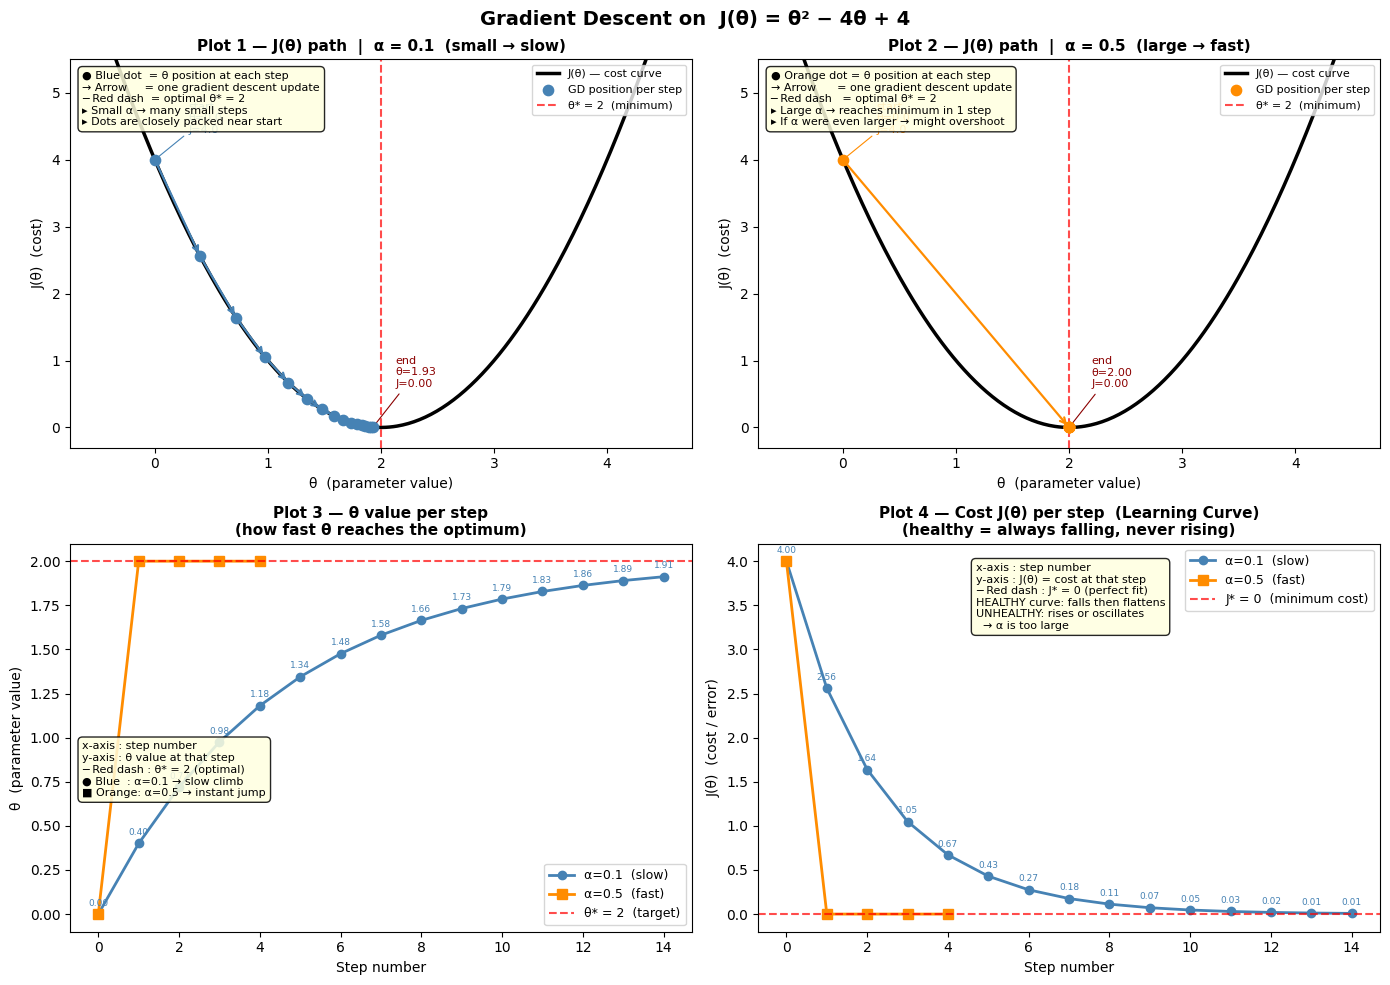

In [30]:
# ══════════════════════════════════════════════════════════════
#  4-PANEL FIGURE
# ══════════════════════════════════════════════════════════════
theta_range = np.linspace(-0.5, 4.5, 300)
thetas1 = np.append(df1["θ (old)"].to_numpy(dtype=float), float(df1["θ (new)"].iloc[-1]))
thetas2 = np.append(df2["θ (old)"].to_numpy(dtype=float), float(df2["θ (new)"].iloc[-1]))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Gradient Descent on  J(θ) = θ² − 4θ + 4", fontsize=14, fontweight="bold")

# ── helper: draw bowl + dots + arrows ────────────────────────
def draw_bowl(ax, thetas, color, alpha_val, title, desc_lines):
    """
    Draws the J(θ) bowl curve, GD steps (dots), movement arrows,
    the optimal line, and a text box explaining the plot elements.
    """
    ax.plot(theta_range, J(theta_range), "k-", linewidth=2.5, label="J(θ) — cost curve")
    ax.scatter(thetas, J(thetas), color=color, zorder=5, s=55, label="GD position per step")

    for i in range(len(thetas) - 1):
        ax.annotate("",
                    xy     =(thetas[i+1], J(thetas[i+1])),
                    xytext =(thetas[i],   J(thetas[i])),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.6))

    ax.axvline(2, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="θ* = 2  (minimum)")

    ax.annotate(f"start\nθ={thetas[0]:.1f}\nJ={J(thetas[0]):.1f}",
                xy=(thetas[0], J(thetas[0])), xytext=(thetas[0]+0.3, J(thetas[0])+0.4),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle="-", color=color, lw=0.8))
    ax.annotate(f"end\nθ={thetas[-1]:.2f}\nJ={J(thetas[-1]):.2f}",
                xy=(thetas[-1], J(thetas[-1])), xytext=(thetas[-1]+0.2, J(thetas[-1])+0.6),
                fontsize=8, color="darkred",
                arrowprops=dict(arrowstyle="-", color="darkred", lw=0.8))

    desc = "\n".join(desc_lines)
    ax.text(0.02, 0.97, desc, transform=ax.transAxes, fontsize=8, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.85))

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("θ  (parameter value)")
    ax.set_ylabel("J(θ)  (cost)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(-0.3, max(J(thetas)) + 1.5)
# ── Plot 1 — bowl + path  α=0.1 ──────────────────────────────
draw_bowl(
    axes[0, 0], thetas1, "steelblue", alpha1,
    title=f"Plot 1 — J(θ) path  |  α = {alpha1}  (small → slow)",
    desc_lines=[
        "● Blue dot  = θ position at each step",
        "→ Arrow     = one gradient descent update",
        "─ Red dash  = optimal θ* = 2",
        "▸ Small α → many small steps",
        "▸ Dots are closely packed near start",
    ]
)

# ── Plot 2 — bowl + path  α=0.5 ──────────────────────────────
draw_bowl(
    axes[0, 1], thetas2, "darkorange", alpha2,
    title=f"Plot 2 — J(θ) path  |  α = {alpha2}  (large → fast)",
    desc_lines=[
        "● Orange dot = θ position at each step",
        "→ Arrow      = one gradient descent update",
        "─ Red dash   = optimal θ* = 2",
        "▸ Large α → reaches minimum in 1 step",
        "▸ If α were even larger → might overshoot",
    ]
)

# ── Plot 3 — θ value over steps ──────────────────────────────
ax3 = axes[1, 0]
ax3.plot(df1["step"], df1["θ (old)"], "o-", color="steelblue",
         linewidth=2, markersize=6, label=f"α={alpha1}  (slow)")
ax3.plot(df2["step"], df2["θ (old)"], "s-", color="darkorange",
         linewidth=2, markersize=7, label=f"α={alpha2}  (fast)")
ax3.axhline(2, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="θ* = 2  (target)")

for i, row in df1.iterrows():
    ax3.annotate(f"{row['θ (old)']:.2f}",
                 xy=(row["step"], row["θ (old)"]),
                 xytext=(0, 6), textcoords="offset points",
                 fontsize=6.5, color="steelblue", ha="center")

ax3.text(0.02, 0.35,
         "x-axis : step number\n"
         "y-axis : θ value at that step\n"
         "─ Red dash : θ* = 2 (optimal)\n"
         "● Blue  : α=0.1 → slow climb\n"
         "■ Orange: α=0.5 → instant jump",
         transform=ax3.transAxes, fontsize=8,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.85))

ax3.set_title("Plot 3 — θ value per step\n(how fast θ reaches the optimum)",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Step number")
ax3.set_ylabel("θ  (parameter value)")
ax3.legend(fontsize=9)

# ── Plot 4 — J(θ) over steps (Learning Curve) ────────────────
ax4 = axes[1, 1]
ax4.plot(df1["step"], df1["J(θ)"], "o-", color="steelblue",
         linewidth=2, markersize=6, label=f"α={alpha1}  (slow)")
ax4.plot(df2["step"], df2["J(θ)"], "s-", color="darkorange",
         linewidth=2, markersize=7, label=f"α={alpha2}  (fast)")
ax4.axhline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="J* = 0  (minimum cost)")

for i, row in df1.iterrows():
    ax4.annotate(f"{row['J(θ)']:.2f}",
                 xy=(row["step"], row["J(θ)"]),
                 xytext=(0, 6), textcoords="offset points",
                 fontsize=6.5, color="steelblue", ha="center")

ax4.text(0.35, 0.95,
         "x-axis : step number\n"
         "y-axis : J(θ) = cost at that step\n"
         "─ Red dash : J* = 0 (perfect fit)\n"
         "HEALTHY curve: falls then flattens\n"
         "UNHEALTHY: rises or oscillates\n"
         "  → α is too large",
         transform=ax4.transAxes, fontsize=8, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.85))

ax4.set_title("Plot 4 — Cost J(θ) per step  (Learning Curve)\n"
              "(healthy = always falling, never rising)",
              fontsize=11, fontweight="bold")
ax4.set_xlabel("Step number")
ax4.set_ylabel("J(θ)  (cost / error)")
ax4.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. Analytical Notes on Cost Functions in Regression

This section illustrates **10 key analytical insights** about cost functions and gradient descent through charts and figures.

| # | Topic |
|---|-------|
| 1 | Convexity of MSE — always one global minimum |
| 2 | Outlier sensitivity — MSE vs MAE |
| 3 | MAE constant gradient near minimum |
| 4 | MAE non-differentiability at zero |
| 5 | Gradient direction — always points uphill |
| 6 | Feature scaling — circular vs elongated contours |
| 7 | Learning rate — too small / just right / too large |
| 8 | Natural step size reduction near minimum |
| 9 | Initialization and local vs global minima |
| 10 | Convergence criteria — when to stop |


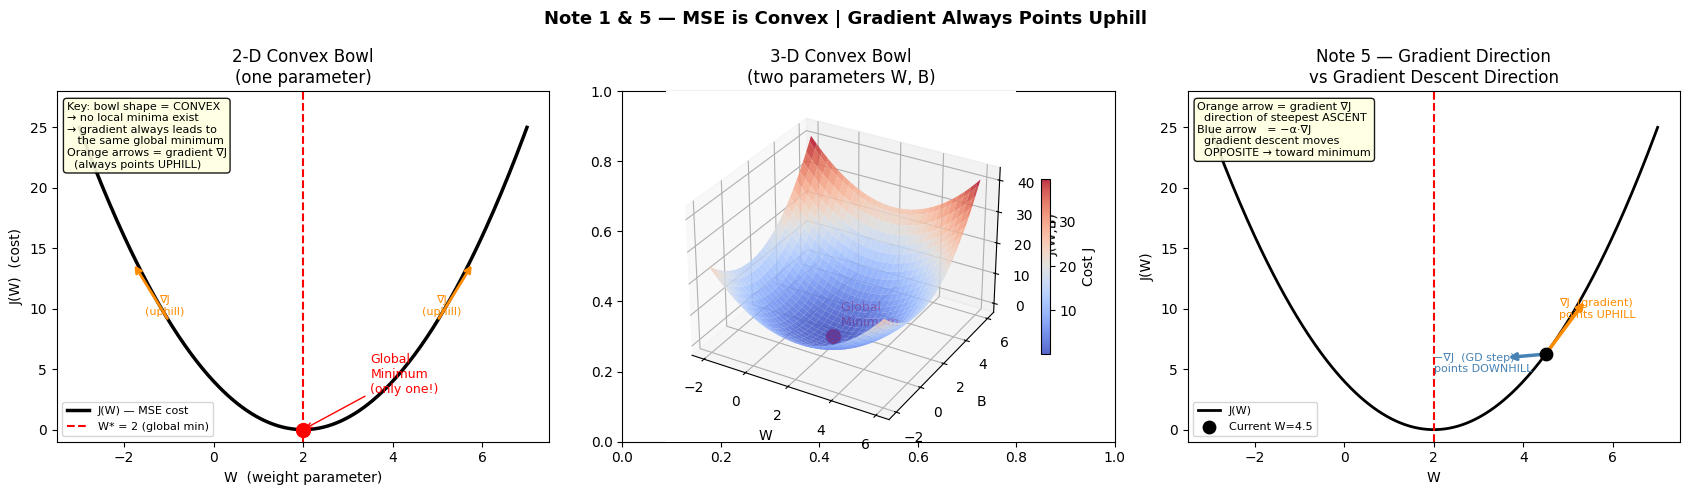

Note 1: MSE is convex — one bowl, one global minimum, gradient descent always finds it.
Note 5: ∇J always points uphill. GD steps in direction −α·∇J (opposite = downhill).


In [31]:
# ══════════════════════════════════════════════════════════════════════════════
#  Notes 1 & 5 — MSE Convexity  +  Gradient Vector Direction
#
#  Note 1: The MSE cost function in linear regression is always fully convex.
#           The parameter space looks like a perfect bowl — no local minima exist.
#           Any minimum found by gradient descent is guaranteed to be the global minimum.
#
#  Note 5: The gradient vector (∇J) at any point in parameter space
#           always points in the direction of steepest ascent (uphill).
#           Gradient descent moves opposite to this vector (= downhill).
# ══════════════════════════════════════════════════════════════════════════════

# ── Build the figure: 3 subplots side by side ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
# Overall figure title
fig.suptitle("Note 1 & 5 — MSE is Convex | Gradient Always Points Uphill",
             fontsize=13, fontweight="bold")

# ── Left plot: 2-D bowl (single parameter W) ─────────────────────────────────
ax = axes[0]

# Horizontal axis: W values from -3 to 7
W_vals = np.linspace(-3, 7, 300)
# Simple cost function: J(W) = (W-2)² — parabola with minimum at W=2
# This is a simplified MSE form used to illustrate convexity
J_vals = (W_vals - 2) ** 2

# Draw the cost curve with a thick black line
ax.plot(W_vals, J_vals, "k-", linewidth=2.5, label="J(W) — MSE cost")
ax.set_xlabel("W  (weight parameter)")  # horizontal axis label: weight value
ax.set_ylabel("J(W)  (cost)")           # vertical axis label: cost value
ax.set_title("2-D Convex Bowl\n(one parameter)")  # plot title

# Mark the minimum point with a red vertical line at W=2
ax.axvline(2, color="red", linestyle="--", linewidth=1.5, label="W* = 2 (global min)")
# Red dot exactly at the bottom of the bowl (W=2, J=0)
ax.scatter([2], [0], color="red", s=100, zorder=6)
# Text annotation with arrow pointing to the minimum
ax.annotate("Global\nMinimum\n(only one!)",
            xy=(2, 0),           # arrow tip coordinates = minimum point
            xytext=(3.5, 3),     # text position
            arrowprops=dict(arrowstyle="->", color="red"), fontsize=9, color="red")

# ── Draw gradient arrows on both sides of the bowl ───────────────────────────
# Goal: show that the gradient always points uphill
for W_pt, direction in [(-1, -1), (5, 1)]:  # -1 = left side, +1 = right side
    grad = 2 * (W_pt - 2)        # compute gradient: ∇J(W) = 2·(W-2) = d/dW[(W-2)²]
    J_pt = (W_pt - 2) ** 2       # cost value at this point

    # Draw orange arrow from current point upward (gradient direction = ascent)
    ax.annotate("",
                xy     =(W_pt + 0.8*np.sign(grad), J_pt + 0.8*abs(grad)),  # arrow tip (higher)
                xytext =(W_pt, J_pt),   # arrow base (current point)
                arrowprops=dict(arrowstyle="->", color="darkorange", lw=2))
    # Text label beside the arrow
    ax.text(W_pt + 0.1*np.sign(grad), J_pt + 0.5, "∇J\n(uphill)",
            fontsize=8, color="darkorange", ha="center")

ax.legend(fontsize=8)
ax.set_ylim(-1, 28)  # vertical axis range
# Info box: summary of the concept in the corner of the plot
ax.text(0.02, 0.97,
        "Key: bowl shape = CONVEX\n"                  # bowl shape = convex
        "→ no local minima exist\n"                   # no local minima
        "→ gradient always leads to\n"                # gradient always leads to
        "   the same global minimum\n"                # the same global minimum
        "Orange arrows = gradient ∇J\n"               # orange arrows = gradient
        "  (always points UPHILL)",                   # always points uphill
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Middle plot: 3-D surface J(W, B) ─────────────────────────────────────────
# This plot shows that even with two parameters, the bowl remains convex
ax_mid = fig.add_subplot(1, 3, 2, projection="3d")  # 3-D subplot in the center

# Build coordinate grid for W and B
W_grid = np.linspace(-2, 6, 60)  # 60 points for W from -2 to 6
B_grid = np.linspace(-2, 6, 60)  # 60 points for B from -2 to 6
WW, BB = np.meshgrid(W_grid, B_grid)  # 2-D matrix of all (W, B) combinations

# Compute cost for every (W, B) combination
# J(W,B) = (W-2)² + (B-1)² — sum of two parabolas
# Minimum at W*=2, B*=1, giving J=0
JJ = (WW - 2)**2 + (BB - 1)**2

# Plot the 3-D surface with a heatmap colormap (blue=low, red=high)
surf = ax_mid.plot_surface(WW, BB, JJ,
                            cmap="coolwarm",  # cool-to-warm colormap
                            alpha=0.85,       # slightly transparent
                            linewidth=0,      # no grid lines
                            antialiased=True) # smooth edges

# Axis labels
ax_mid.set_xlabel("W")
ax_mid.set_ylabel("B")
ax_mid.set_zlabel("J(W,B)")
ax_mid.set_title("3-D Convex Bowl\n(two parameters W, B)")

# Global minimum point marked with a red star
ax_mid.scatter([2], [1], [0], color="red", s=100, zorder=10)
ax_mid.text(2, 1, 3, "  Global\n  Minimum", color="red", fontsize=9)

# Colorbar to show cost magnitude
fig.colorbar(surf, ax=ax_mid, shrink=0.5, label="Cost J")

# ── Right plot: compare gradient direction vs gradient descent direction ───────
ax = axes[2]

# Draw the cost curve again
ax.plot(W_vals, J_vals, "k-", linewidth=2, label="J(W)")
# Red dashed vertical line = minimum location
ax.axvline(2, color="red", linestyle="--", linewidth=1.5)

# ── Mark a point on the bowl to compare the two directions ───────────────────
W_ex = 4.5           # a point on the right slope of the bowl (above the minimum)
J_ex = (W_ex - 2) ** 2   # cost at this point = (4.5-2)² = 6.25
g_ex = 2 * (W_ex - 2)    # gradient at this point = 2·(4.5-2) = +5 (positive = rightward)

# Orange arrow: gradient direction (∇J) — pointing uphill (ascent)
# This is the direction in which the cost function increases
ax.annotate("",
            xy=(W_ex + 0.9, J_ex + 0.9 * g_ex),   # arrow tip: right and up
            xytext=(W_ex, J_ex),                    # arrow base: current point
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=2.5))
ax.text(W_ex + 0.3, J_ex + g_ex * 0.5 + 0.5,
        "∇J  (gradient)\npoints UPHILL",  # gradient points uphill
        fontsize=8, color="darkorange")

# Blue arrow: gradient descent direction (−α·∇J) — opposite to gradient = downhill
# This is the direction the algorithm moves to reach the minimum
ax.annotate("",
            xy=(W_ex - 0.9, J_ex - 0.3),   # arrow tip: left and down
            xytext=(W_ex, J_ex),            # arrow base: current point
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=2.5))
ax.text(W_ex - 2.5, J_ex - 1.5,
        "−∇J  (GD step)\npoints DOWNHILL",  # GD step points downhill
        fontsize=8, color="steelblue")

# Mark the current point with a black circle
ax.scatter([W_ex], [J_ex], color="black", s=80, zorder=6, label=f"Current W={W_ex}")
ax.set_xlabel("W")
ax.set_ylabel("J(W)")
ax.set_title("Note 5 — Gradient Direction\nvs Gradient Descent Direction")
ax.legend(fontsize=8)
ax.set_ylim(-1, 28)

# Final info box
ax.text(0.02, 0.97,
        "Orange arrow = gradient ∇J\n"        # orange arrow = gradient
        "  direction of steepest ASCENT\n"    # direction of steepest ascent
        "Blue arrow   = −α·∇J\n"             # blue arrow = GD step
        "  gradient descent moves\n"          # GD moves in this direction
        "  OPPOSITE → toward minimum",        # opposite to gradient → toward minimum
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()   # auto-adjust spacing between subplots
plt.show()

# ── Summary print ─────────────────────────────────────────────────────────────
print("Note 1: MSE is convex — one bowl, one global minimum, gradient descent always finds it.")
print("Note 5: ∇J always points uphill. GD steps in direction −α·∇J (opposite = downhill).")


Cost comparison at the outlier-contaminated dataset:
  MSE-fit line  — MSE=13.60  MAE=2.11
  MAE-fit line  — MSE=14.86  MAE=1.41
  Clean-data fit: slope=1.997  intercept=1.243
  MSE-fit slope : 1.997   (pulled toward outlier)
  MAE-fit slope : 2.003   (more robust)


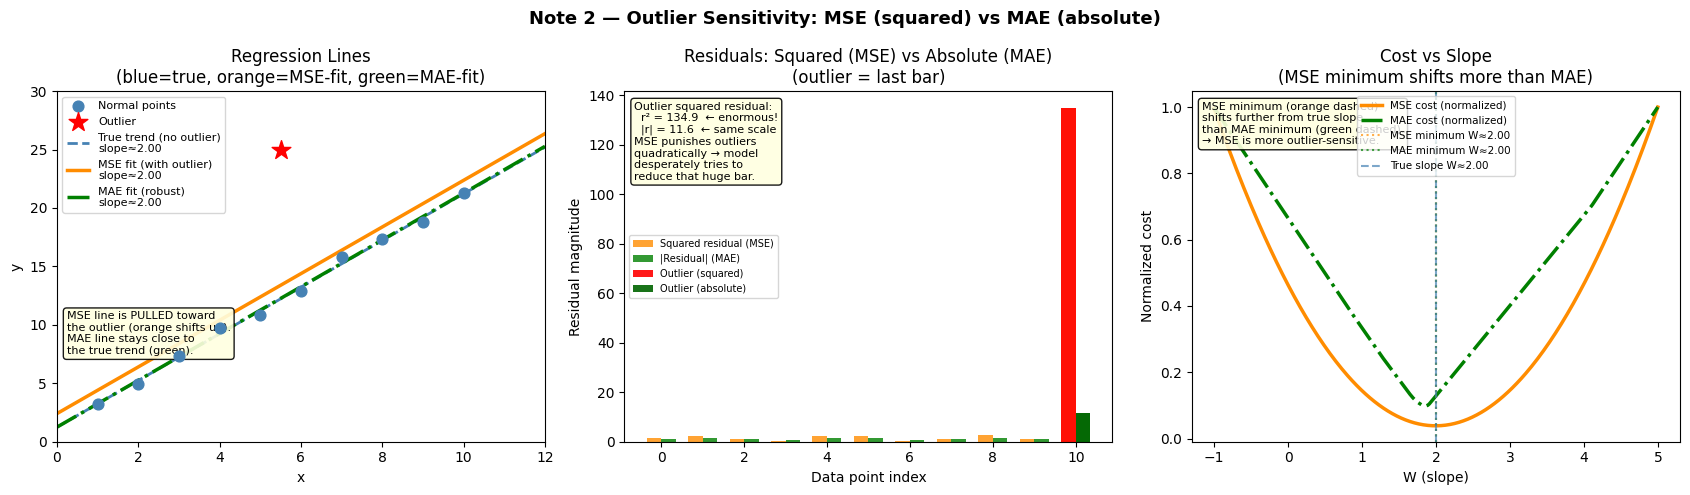

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
#  Note 2 — Outlier Sensitivity: Comparing MSE and MAE
#
#  In MSE, errors are squared.
#  If one point has an error of 10, its penalty is 100.
#  If another has an error of 2, its penalty is only 4.
#  → A single outlier with a large error dominates the total cost.
#  → The model desperately tries to reduce that outlier's error
#     and pulls the regression line toward it.
#
#  In MAE, errors are absolute values:
#  error of 10 → penalty of 10  (not 100)
#  → The outlier's influence is linear, not quadratic → more robust.
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np          # numerical computation library
import matplotlib.pyplot as plt  # plotting library
from scipy.optimize import minimize  # for MAE optimization (no closed-form solution)

np.random.seed(42)  # fix random seed for reproducibility

# ── Build clean dataset (no outlier) ─────────────────────────────────────────
# x = feature values (e.g. house floor area)
x_clean = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
# y = true target values: y = 2x + 1 + small random noise
# np.random.normal(0, 0.5, n): Gaussian noise with mean 0 and std 0.5
y_clean = 2.0 * x_clean + 1.0 + np.random.normal(0, 0.5, len(x_clean))

# ── Add one outlier to the dataset ───────────────────────────────────────────
# np.append: adds a value to the end of an array
x_out = np.append(x_clean, 5.5)   # outlier x is near the middle of the range
y_out = np.append(y_clean, 25.0)  # outlier y is far above the trend (should be ≈12)
# This outlier is chosen near the center of x
# because central outliers have the largest effect on the regression slope

# ── Fit regression line with MSE (least squares) ─────────────────────────────
# np.polyfit(x, y, 1): linear regression = minimizes Σ(yhat-y)² = MSE
# degree 1 = straight line
slope_clean, intercept_clean = np.polyfit(x_clean, y_clean, 1)  # without outlier
slope_out,   intercept_out   = np.polyfit(x_out,   y_out,   1)  # with outlier

# ── Define MAE cost function for numerical optimization ───────────────────────
def mae_cost(params, x, y):
    """
    MAE = (1/n) · Σ |W·xᵢ + B − yᵢ|
    params = [W, B]: model parameters (slope and intercept)
    MAE has no closed-form solution like MSE → must be minimized numerically
    """
    W, B = params              # unpack parameters from input argument
    return np.mean(np.abs(W * x + B - y))  # mean of absolute errors

# Numerical optimization to find W and B that minimize MAE
# x0=[2.0, 1.0]: initial guess (slope=2, intercept=1)
# method="Nelder-Mead": derivative-free optimization (suitable for MAE which has no gradient at 0)
res_mae = minimize(mae_cost, x0=[2.0, 1.0], args=(x_out, y_out), method="Nelder-Mead")
slope_mae, intercept_mae = res_mae.x  # extract the optimal parameters found

# ── Helper functions for computing MSE and MAE ───────────────────────────────
x_line = np.linspace(0, 12, 200)  # 200 points for drawing regression lines

def mse_val(slope, intercept, x, y):
    """Mean Squared Error: MSE = (1/n)·Σ(slope·xᵢ + intercept − yᵢ)²"""
    return np.mean((slope * x + intercept - y)**2)

def mae_val(slope, intercept, x, y):
    """Mean Absolute Error: MAE = (1/n)·Σ|slope·xᵢ + intercept − yᵢ|"""
    return np.mean(np.abs(slope * x + intercept - y))

# ── Print numeric comparison ──────────────────────────────────────────────────
print("=" * 60)
print("Cost comparison at the outlier-contaminated dataset:")
print(f"  MSE-fit line  — MSE={mse_val(slope_out, intercept_out, x_out, y_out):.2f}  MAE={mae_val(slope_out, intercept_out, x_out, y_out):.2f}")
print(f"  MAE-fit line  — MSE={mse_val(slope_mae, intercept_mae, x_out, y_out):.2f}  MAE={mae_val(slope_mae, intercept_mae, x_out, y_out):.2f}")
print(f"  Clean-data fit: slope={slope_clean:.3f}  intercept={intercept_clean:.3f}")
print(f"  MSE-fit slope : {slope_out:.3f}   (pulled toward outlier)")  # dragged toward the outlier
print(f"  MAE-fit slope : {slope_mae:.3f}   (more robust)")            # more resistant to outliers

# ── Build 3 subplots side by side ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Note 2 — Outlier Sensitivity: MSE (squared) vs MAE (absolute)",
             fontsize=13, fontweight="bold")

# ── Left plot: regression lines comparison ───────────────────────────────────
ax = axes[0]
# Plot normal points as blue circles
ax.scatter(x_clean, y_clean, color="steelblue", s=60, zorder=5, label="Normal points")
# Plot the outlier as a large red star (zorder=6 places it on top)
ax.scatter([5.5], [25.0], color="red", s=200, marker="*", zorder=6, label="Outlier")

# Blue dashed line: true data trend (unaffected by outlier)
ax.plot(x_line, slope_clean * x_line + intercept_clean, "steelblue",
        linestyle="--", linewidth=2, label=f"True trend (no outlier)\nslope≈{slope_clean:.2f}")

# Orange line: MSE fit with outlier — pulled toward the outlier
ax.plot(x_line, slope_out * x_line + intercept_out, "darkorange",
        linewidth=2.5, label=f"MSE fit (with outlier)\nslope≈{slope_out:.2f}")

# Green dash-dot line: MAE fit with outlier — stays closer to the true trend
ax.plot(x_line, slope_mae * x_line + intercept_mae, "green",
        linewidth=2.5, linestyle="-.", label=f"MAE fit (robust)\nslope≈{slope_mae:.2f}")

ax.set_xlabel("x")            # horizontal axis label
ax.set_ylabel("y")            # vertical axis label
ax.set_title("Regression Lines\n(blue=true, orange=MSE-fit, green=MAE-fit)")
ax.legend(fontsize=8)
ax.set_xlim(0, 12)            # x display range
ax.set_ylim(0, 30)            # y display range
ax.text(0.02, 0.25,
        "MSE line is PULLED toward\n"   # MSE line is pulled toward the outlier
        "the outlier (orange shifts up).\n"
        "MAE line stays close to\n"     # MAE line stays near the true trend
        "the true trend (green).",
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Middle plot: squared vs absolute residuals comparison ─────────────────────
ax = axes[1]

# Compute MSE model predictions for all points (including outlier)
y_pred_mse = slope_out * x_out + intercept_out  # ŷᵢ = W·xᵢ + B

residuals = y_out - y_pred_mse  # errors: rᵢ = yᵢ − ŷᵢ  (actual minus predicted)
sq_res = residuals ** 2         # squared errors: rᵢ² (for MSE)
ab_res = np.abs(residuals)      # absolute errors: |rᵢ| (for MAE)

# Draw grouped bar chart
width = 0.35     # bar width
idx   = np.arange(len(x_out))  # data point indices [0,1,2,...,10]

# Orange bars: squared errors (MSE)
bars1 = ax.bar(idx - width/2, sq_res, width, color="darkorange", alpha=0.8,
               label="Squared residual (MSE)")
# Green bars: absolute errors (MAE)
bars2 = ax.bar(idx + width/2, ab_res, width, color="green",      alpha=0.8,
               label="|Residual| (MAE)")

# Highlight the outlier bar (last data point)
ax.bar([len(x_out)-1 - width/2], [sq_res[-1]], width, color="red",       alpha=0.9,
       label="Outlier (squared)")    # squared error of the outlier = enormous!
ax.bar([len(x_out)-1 + width/2], [ab_res[-1]], width, color="darkgreen",  alpha=0.9,
       label="Outlier (absolute)")   # absolute error of the outlier = same scale

ax.set_xlabel("Data point index")   # data point index
ax.set_ylabel("Residual magnitude") # error magnitude
ax.set_title("Residuals: Squared (MSE) vs Absolute (MAE)\n(outlier = last bar)")
ax.legend(fontsize=7)
ax.text(0.02, 0.97,
        "Outlier squared residual:\n"
        f"  r² = {sq_res[-1]:.1f}  ← enormous!\n"  # squared outlier error is huge
        f"  |r| = {ab_res[-1]:.1f}  ← same scale\n"  # absolute error stays on same scale
        "MSE punishes outliers\n"         # MSE penalizes outliers
        "quadratically → model\n"         # quadratically
        "desperately tries to\n"
        "reduce that huge bar.",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Right plot: cost surface (MSE and MAE) vs slope W ────────────────────────
ax = axes[2]

# Range of W values for plotting the cost surface
W_range = np.linspace(-1, 5, 300)
B_fixed = intercept_out  # keep B fixed and vary only W

# Compute MSE and MAE cost for each W value
# list comprehension: for each w in range, compute the cost
mse_curve = [mse_val(w, B_fixed, x_out, y_out) for w in W_range]
mae_curve = [mae_val(w, B_fixed, x_out, y_out) for w in W_range]

# Normalize for visual comparison (scale both curves to [0,1])
mse_norm = np.array(mse_curve) / max(mse_curve)  # divide by maximum MSE
mae_norm = np.array(mae_curve) / max(mae_curve)  # divide by maximum MAE

# Draw cost curves
ax.plot(W_range, mse_norm, "darkorange", linewidth=2.5, label="MSE cost (normalized)")
ax.plot(W_range, mae_norm, "green",      linewidth=2.5, linestyle="-.", label="MAE cost (normalized)")

# Vertical lines at each cost function's minimum
ax.axvline(slope_out,   color="darkorange", linestyle=":", alpha=0.7,
           label=f"MSE minimum W≈{slope_out:.2f}")   # MSE minimum farther from true slope
ax.axvline(slope_mae,   color="green",      linestyle=":", alpha=0.7,
           label=f"MAE minimum W≈{slope_mae:.2f}")   # MAE minimum closer to true slope
ax.axvline(slope_clean, color="steelblue",  linestyle="--", alpha=0.7,
           label=f"True slope W≈{slope_clean:.2f}")  # true slope (without outlier)

ax.set_xlabel("W (slope)")           # horizontal axis: slope value
ax.set_ylabel("Normalized cost")     # vertical axis: normalized cost
ax.set_title("Cost vs Slope\n(MSE minimum shifts more than MAE)")
ax.legend(fontsize=7.5)
ax.text(0.02, 0.97,
        "MSE minimum (orange dashed)\n"    # MSE minimum (orange)
        "shifts further from true slope\n" # shifts further from the true slope
        "than MAE minimum (green dashed).\n"
        "→ MSE is more outlier-sensitive.",  # MSE is more sensitive to outliers
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # auto-adjust spacing between subplots
plt.show()


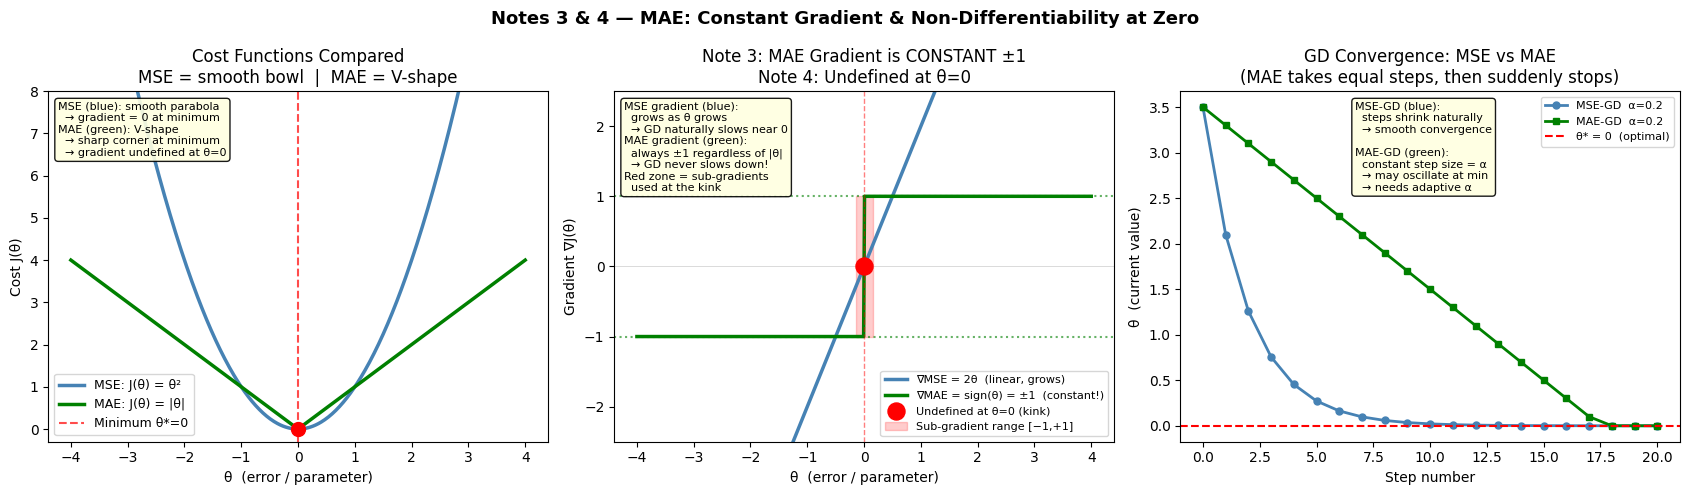

Note 3: MAE gradient is always ±1 → GD does not slow near minimum without adaptive learning rate.
Note 4: MAE is not differentiable at θ=0 → sub-gradients (any value in [-1,+1]) are used in practice.


In [35]:
# =============================================================================

# Note 3: In MAE, the gradient of the function sign(θ) = ±1 — a constant value
# meaning that no matter how close we are to the minimum,
# the step size does not naturally decrease.
# The algorithm may oscillate around the minimum
# unless we manually reduce the learning rate.
#
# Note 4: At the exact point θ=0 (where the error is zero),
# MAE = |θ| is not differentiable (has a sharp crank).
# In practice, a "sub-gradient" is used:
# Any number in the interval [−1, +1] can be accepted as the gradient at this point.
# ══════════════════════════════════════════════════════════════════════════════
# ── Build 3 subplots side by side ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Notes 3 & 4 — MAE: Constant Gradient & Non-Differentiability at Zero",
             fontsize=13, fontweight="bold")

# ── Shared θ axis for all plots ───────────────────────────────────────────────
theta = np.linspace(-4, 4, 500)  # 500 points in the range [-4, +4] for θ

# ── Compute cost functions and gradients ──────────────────────────────────────

# MSE: smooth parabolic function
mse_func = theta ** 2      # J_MSE(θ) = θ²  ← smooth, differentiable everywhere
mse_grad = 2 * theta       # ∇J_MSE = 2θ  ← linear gradient, grows with distance from zero

# MAE: V-shaped function with a sharp kink at zero
mae_func = np.abs(theta)   # J_MAE(θ) = |θ|  ← V-shape, not differentiable at θ=0

# MAE gradient: np.sign means:
#   sign(θ) = +1  if θ > 0
#   sign(θ) = -1  if θ < 0
#   sign(0) = 0   (but in reality undefined)
mae_grad = np.sign(theta)

# Remove the exact point θ=0 from the gradient plot since it is undefined
mae_grad_display = np.where(theta == 0, np.nan, mae_grad)
# np.where(condition, value_if_true, value_if_false)
# when theta==0 → nan (empty) → not displayed on the plot

# ── Left plot: cost function shapes ──────────────────────────────────────────
ax = axes[0]

# Draw MSE: blue parabolic curve
ax.plot(theta, mse_func, "steelblue", linewidth=2.5, label="MSE: J(θ) = θ²")
# Draw MAE: green V-shape curve
ax.plot(theta, mae_func, "green",     linewidth=2.5, label="MAE: J(θ) = |θ|")

# Red vertical line = minimum of both functions (both have minimum at θ=0)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="Minimum θ*=0")
# Minimum point on the plot
ax.scatter([0], [0], color="red", s=100, zorder=6)

ax.set_xlabel("θ  (error / parameter)")  # x-axis: error or parameter
ax.set_ylabel("Cost J(θ)")               # y-axis: cost value
ax.set_title("Cost Functions Compared\nMSE = smooth bowl  |  MAE = V-shape")
ax.legend(fontsize=9)
ax.set_ylim(-0.3, 8)  # y display range
ax.text(0.02, 0.97,
        "MSE (blue): smooth parabola\n"   # MSE: smooth parabola
        "  → gradient = 0 at minimum\n"   # gradient = 0 at minimum (natural)
        "MAE (green): V-shape\n"           # MAE: V-shape
        "  → sharp corner at minimum\n"   # sharp corner at minimum
        "  → gradient undefined at θ=0",  # gradient undefined at θ=0
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Middle plot: gradient comparison ─────────────────────────────────────────
ax = axes[1]

# Draw MSE gradient: blue line with constant slope (linear)
# The further from the minimum, the larger the gradient → larger steps
ax.plot(theta, mse_grad, "steelblue", linewidth=2.5, label="∇MSE = 2θ  (linear, grows)")

# Draw MAE gradient: green constant line (±1)
# Note: mae_grad_display has nan at θ=0 → gap in the plot
ax.plot(theta, mae_grad_display, "green", linewidth=2.5,
        label="∇MAE = sign(θ) = ±1  (constant!)")

# Mark the kink point (θ=0) where the derivative is undefined
ax.scatter([0], [0], color="red", s=150, marker="o", zorder=6,
           label="Undefined at θ=0 (kink)")  # open circle = undefined

# Reference lines
ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.5)  # vertical line at zero
ax.axhline(0, color="grey", linestyle="-",  linewidth=0.5, alpha=0.4)  # horizontal axis

# Horizontal lines at ±1 to highlight the constant MAE gradient
ax.axhline(+1, color="green", linestyle=":", linewidth=1.5, alpha=0.6)  # MAE gradient right side
ax.axhline(-1, color="green", linestyle=":", linewidth=1.5, alpha=0.6)  # MAE gradient left side

# Sub-gradient region: at θ=0 any value between -1 and +1 is a valid sub-gradient
# fill_betweenx(y_range, x_left, x_right): fills the region between two x values
ax.fill_betweenx([-1, 1], -0.15, 0.15, alpha=0.2, color="red",
                  label="Sub-gradient range [−1,+1]")  # valid sub-gradients at the kink

ax.set_xlabel("θ  (error / parameter)")
ax.set_ylabel("Gradient ∇J(θ)")       # gradient value
ax.set_title("Note 3: MAE Gradient is CONSTANT ±1\nNote 4: Undefined at θ=0")
ax.legend(fontsize=8)
ax.set_ylim(-2.5, 2.5)  # gradient display range
ax.text(0.02, 0.97,
        "MSE gradient (blue):\n"         # MSE gradient (blue):
        "  grows as θ grows\n"           # grows as distance from minimum increases
        "  → GD naturally slows near 0\n"# GD naturally slows near the minimum
        "MAE gradient (green):\n"        # MAE gradient (green):
        "  always ±1 regardless of |θ|\n"# always ±1, regardless of distance
        "  → GD never slows down!\n"     # GD never slows down!
        "Red zone = sub-gradients\n"     # red zone = sub-gradients
        "  used at the kink",            # used at the kink point
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Right plot: GD convergence simulation for MSE and MAE ────────────────────
ax = axes[2]

alpha_sim  = 0.2    # learning rate (same for both)
n_steps    = 20     # number of simulation steps
theta_start = 3.5   # shared starting point

# ── Gradient descent simulation for MSE ──────────────────────────────────────
# J(θ) = θ², ∇J(θ) = 2θ
# Update rule: θ_new = θ_old − α·∇J = θ_old − α·2θ_old
thetas_mse = [theta_start]    # list of θ values at each step
for _ in range(n_steps):
    # compute gradient and update θ
    thetas_mse.append(thetas_mse[-1] - alpha_sim * 2 * thetas_mse[-1])
    # thetas_mse[-1]: last θ in the list
    # multiply by 2: gradient coefficient for J(θ)=θ² is ∇J=2θ

# ── Gradient descent simulation for MAE ──────────────────────────────────────
# J(θ) = |θ|, ∇J(θ) = sign(θ) = ±1
# Update rule: θ_new = θ_old − α·sign(θ_old)
thetas_mae = [theta_start]
for _ in range(n_steps):
    t = thetas_mae[-1]  # current θ
    if abs(t) < alpha_sim:
        # if θ is smaller than the learning rate, the next step would overshoot the minimum
        # to avoid oscillation, jump directly to the minimum
        thetas_mae.append(0.0)
    else:
        # normal step: move opposite to sign(θ)
        # np.sign(t): if t>0 → +1, if t<0 → -1
        thetas_mae.append(t - alpha_sim * np.sign(t))

# Step index array for the x-axis
steps_mse = np.arange(len(thetas_mse))
steps_mae = np.arange(len(thetas_mae))

# Plot MSE convergence path
ax.plot(steps_mse, thetas_mse, "o-", color="steelblue", linewidth=2, markersize=5,
        label=f"MSE-GD  α={alpha_sim}")

# Plot MAE convergence path
ax.plot(steps_mae, thetas_mae, "s-", color="green",     linewidth=2, markersize=5,
        label=f"MAE-GD  α={alpha_sim}")

# Red horizontal line = optimal value (minimum of both functions = θ*=0)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5, label="θ* = 0  (optimal)")

ax.set_xlabel("Step number")       # x-axis: step index
ax.set_ylabel("θ  (current value)")  # y-axis: θ value at each step
ax.set_title("GD Convergence: MSE vs MAE\n(MAE takes equal steps, then suddenly stops)")
ax.legend(fontsize=8)
ax.text(0.35, 0.97,
        "MSE-GD (blue):\n"          # MSE gradient descent (blue):
        "  steps shrink naturally\n" # steps shrink naturally
        "  → smooth convergence\n\n" # → smooth and continuous convergence
        "MAE-GD (green):\n"          # MAE gradient descent (green):
        "  constant step size = α\n" # constant step size = α
        "  → may oscillate at min\n" # → may oscillate around minimum
        "  → needs adaptive α",      # → needs adaptive learning rate
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # auto-adjust spacing
plt.show()

# ── Summary print ─────────────────────────────────────────────────────────────
print("Note 3: MAE gradient is always ±1 → GD does not slow near minimum without adaptive learning rate.")
print("Note 4: MAE is not differentiable at θ=0 → sub-gradients (any value in [-1,+1]) are used in practice.")


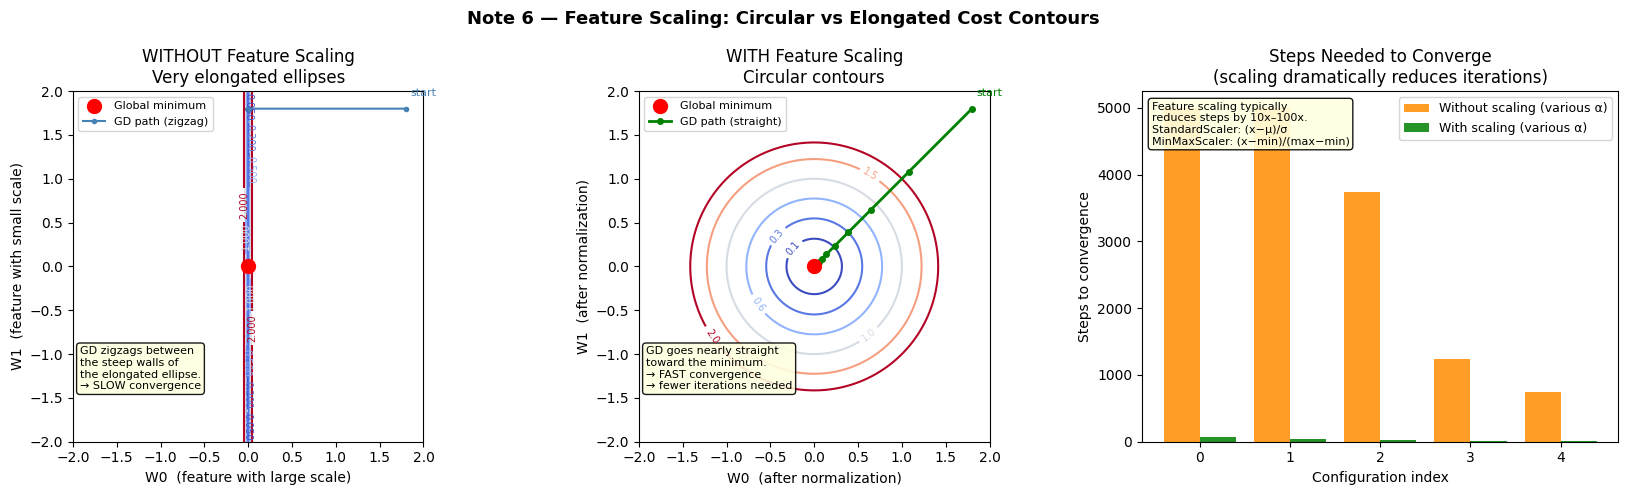

Note 6: Feature scaling transforms elongated elliptical contours to circular ones.
        GD path becomes direct instead of zigzag → much faster convergence.


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
#  Note 6 — The Critical Importance of Feature Scaling
#
#  Suppose we have two features:
#    x₀: house floor area (values between 50 and 500 m²)
#    x₁: number of rooms (values between 1 and 5)
#
#  In this case, weight W₀ must be very small (because x₀ is large)
#  while weight W₁ can be larger.
#  The cost function landscape becomes a stretched ellipse:
#    → W₀ axis is very narrow, W₁ axis is very wide
#    → gradient descent zigzags along the ellipse walls
#    → convergence is very slow
#
#  After normalization (e.g., StandardScaler):
#    both features have similar scale → cost contours become circular
#    → GD goes nearly straight to the minimum → fast convergence
# ══════════════════════════════════════════════════════════════════════════════

# ── Build 3 subplots side by side ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Note 6 — Feature Scaling: Circular vs Elongated Cost Contours",
             fontsize=13, fontweight="bold")

# ── Build parameter grid (W0, W1) for drawing contours ───────────────────────
W0_range = np.linspace(-2, 2, 300)  # 300 values for W0 from -2 to +2
W1_range = np.linspace(-2, 2, 300)  # 300 values for W1 from -2 to +2

# np.meshgrid: creates two 2-D matrices from two 1-D arrays
# WW0[i,j] = W0_range[j], WW1[i,j] = W1_range[i]
# used to evaluate J(W0, W1) over all combinations
WW0, WW1 = np.meshgrid(W0_range, W1_range)

# ── Define cost functions with and without scaling ────────────────────────────

# Cost without scaling: J = scale_big·W0² + scale_small·W1²
# Represents the case where x₀ has a large scale (e.g. area=500)
# and x₁ has a small scale (e.g. rooms=1-5).
# Coefficient 1000 for W0² → W0 axis becomes very narrow (sensitive)
# Coefficient 0.001 for W1² → W1 axis becomes very wide (slow)
J_unscaled = 1000 * WW0**2 + 0.001 * WW1**2

# Cost with scaling: J = W0² + W1²
# After normalization, both features have similar scale
# → equal coefficients → circular contours
J_scaled = WW0**2 + WW1**2

# ── Left plot: contours without scaling ──────────────────────────────────────
ax = axes[0]

# Contour levels (fixed J values at which to draw contour lines)
levels_ell = [0.005, 0.05, 0.2, 0.5, 1.0, 2.0]

# ax.contour: draw contour lines on a 2-D map
# each line = set of points where J(W0,W1) equals a fixed value
cs1 = ax.contour(WW0, WW1, J_unscaled, levels=levels_ell, cmap="coolwarm")
ax.clabel(cs1, fontsize=7)  # label each contour line with its J value

ax.set_aspect("equal")  # equal aspect ratio → circles appear as circles
ax.set_xlabel("W0  (feature with large scale)")  # W0 axis (large-scale feature)
ax.set_ylabel("W1  (feature with small scale)")  # W1 axis (small-scale feature)
ax.set_title("WITHOUT Feature Scaling\nVery elongated ellipses")
ax.scatter([0], [0], color="red", s=100, zorder=6, label="Global minimum")

# ── Simulate GD path on the unscaled surface (zigzag) ────────────────────────
# Learning rate must be small because the gradient along W0 is enormous
alpha_unscaled = 0.0005

w0, w1 = 1.8, 1.8      # starting point: upper-right corner
path_unscaled = [(w0, w1)]  # list to track the path

for _ in range(30):  # 30 steps
    # Gradient of J w.r.t. W0: ∂J/∂W0 = 2·1000·W0 = 2000·W0
    # (coefficient 1000 comes from J = 1000·W0²)
    dw0 = 2000 * w0

    # Gradient of J w.r.t. W1: ∂J/∂W1 = 2·0.001·W1 = 0.002·W1
    # (coefficient 0.001 comes from J = 0.001·W1²)
    dw1 = 0.002 * w1

    # Update W0 and W1 using gradient descent rule: W_new = W_old - α·∇J
    w0 = w0 - alpha_unscaled * dw0
    w1 = w1 - alpha_unscaled * dw1
    path_unscaled.append((w0, w1))

# Convert list to NumPy array for easy plotting
path_unscaled = np.array(path_unscaled)

# Draw GD path: blue line with dots
ax.plot(path_unscaled[:, 0], path_unscaled[:, 1],
        "steelblue", linewidth=1.5, marker="o", markersize=3,
        label="GD path (zigzag)")  # zigzag path

# Mark the starting point
ax.annotate("start", xy=path_unscaled[0], fontsize=8, color="steelblue",
            xytext=(path_unscaled[0,0]+0.05, path_unscaled[0,1]+0.15))
ax.legend(fontsize=8)
ax.text(0.02, 0.15,
        "GD zigzags between\n"         # GD zigzags between
        "the steep walls of\n"         # the steep walls of the elongated ellipse
        "the elongated ellipse.\n"
        "→ SLOW convergence",          # → slow convergence
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Middle plot: contours with scaling ───────────────────────────────────────
ax = axes[1]

levels_circ = [0.1, 0.3, 0.6, 1.0, 1.5, 2.0]  # levels for circular contours
cs2 = ax.contour(WW0, WW1, J_scaled, levels=levels_circ, cmap="coolwarm")
ax.clabel(cs2, fontsize=7)  # label each contour line with its J value

ax.set_aspect("equal")       # equal aspect ratio
ax.set_xlabel("W0  (after normalization)")   # after normalization
ax.set_ylabel("W1  (after normalization)")
ax.set_title("WITH Feature Scaling\nCircular contours")
ax.scatter([0], [0], color="red", s=100, zorder=6, label="Global minimum")

# ── Simulate GD path on the scaled surface (straight) ────────────────────────
# Larger learning rate is allowed because gradients are balanced
alpha_scaled = 0.2

w0, w1 = 1.8, 1.8           # same starting point
path_scaled = [(w0, w1)]     # path list

for _ in range(12):  # only 12 steps are enough (much faster than 30)
    # Gradient of J=W0²+W1² w.r.t. W0: ∂J/∂W0 = 2·W0
    dw0 = 2 * w0
    # Gradient of J=W0²+W1² w.r.t. W1: ∂J/∂W1 = 2·W1
    dw1 = 2 * w1

    # Update parameters
    w0 = w0 - alpha_scaled * dw0  # W0_new = W0 - α·2·W0
    w1 = w1 - alpha_scaled * dw1  # W1_new = W1 - α·2·W1
    path_scaled.append((w0, w1))

path_scaled = np.array(path_scaled)

# Draw straight GD path in green
ax.plot(path_scaled[:, 0], path_scaled[:, 1],
        "green", linewidth=2, marker="o", markersize=4,
        label="GD path (straight)")  # straight path

ax.annotate("start", xy=path_scaled[0], fontsize=8, color="green",
            xytext=(path_scaled[0,0]+0.05, path_scaled[0,1]+0.15))
ax.legend(fontsize=8)
ax.text(0.02, 0.15,
        "GD goes nearly straight\n"    # GD goes nearly straight
        "toward the minimum.\n"
        "→ FAST convergence\n"         # → fast convergence
        "→ fewer iterations needed",   # → fewer iterations needed
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Right plot: convergence step count comparison ─────────────────────────────
ax = axes[2]

def count_steps_to_converge(scale_ratio, alpha, tol=1e-3, max_iter=2000):
    """
    Returns the number of steps needed to reach |W| < tol.
    scale_ratio: ratio of feature scales (larger = more elongated ellipse)
    alpha: learning rate
    tol: convergence threshold (how close to minimum we need to get)
    max_iter: maximum iterations (returned if convergence is not reached)
    """
    w0, w1 = 1.8, 1.8  # starting point
    for i in range(max_iter):
        # gradient with scale ratio: W0 axis is hard, W1 axis is easy
        dw0 = 2 * scale_ratio * w0  # gradient along elongated axis
        dw1 = 2 / scale_ratio * w1  # gradient along compressed axis
        w0 = w0 - alpha * dw0
        w1 = w1 - alpha * w1 * 2   # gradient for scaled W1 surface
        # stop condition: Euclidean distance from minimum less than tol
        if np.sqrt(w0**2 + w1**2) < tol:
            return i
    return max_iter  # did not converge, return max iterations

# Compute step count for 5 different α values, with and without scaling
alphas_unscaled = [0.0001, 0.0003, 0.001, 0.003, 0.005]  # small α values (unscaled)
alphas_scaled   = [0.05,   0.1,    0.15,  0.2,   0.25]   # larger α values (scaled)

steps_unscaled_list = []  # step counts without scaling
steps_scaled_list   = []  # step counts with scaling

# Without scaling: scale_ratio=31.6 simulates a large scale difference
for a in alphas_unscaled:
    su = count_steps_to_converge(scale_ratio=31.6, alpha=a, max_iter=5000)
    steps_unscaled_list.append(su)

# With scaling: scale_ratio=1.0 means equal scales
for a in alphas_scaled:
    ss = count_steps_to_converge(scale_ratio=1.0, alpha=a, max_iter=5000)
    steps_scaled_list.append(ss)

# Draw grouped bar chart
x_bar = np.arange(5)   # indices for 5 configurations

# Orange bars: without scaling
bars1 = ax.bar(x_bar - 0.2, steps_unscaled_list, 0.4,
               color="darkorange", alpha=0.85, label="Without scaling (various α)")

# Green bars: with scaling
bars2 = ax.bar(x_bar + 0.2, steps_scaled_list,   0.4,
               color="green",      alpha=0.85, label="With scaling (various α)")

ax.set_xlabel("Configuration index")   # configuration index (each experiment)
ax.set_ylabel("Steps to convergence")  # number of steps to convergence
ax.set_title("Steps Needed to Converge\n(scaling dramatically reduces iterations)")
ax.legend(fontsize=9)
ax.text(0.02, 0.97,
        "Feature scaling typically\n"        # feature scaling typically
        "reduces steps by 10x–100x.\n"       # reduces steps by 10x–100x
        "StandardScaler: (x−μ)/σ\n"          # standardization: (x-mean)/std
        "MinMaxScaler: (x−min)/(max−min)",   # Min-Max scaling: to [0,1] range
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # auto-adjust spacing
plt.show()

# ── Summary print ─────────────────────────────────────────────────────────────
print("Note 6: Feature scaling transforms elongated elliptical contours to circular ones.")
print("        GD path becomes direct instead of zigzag → much faster convergence.")


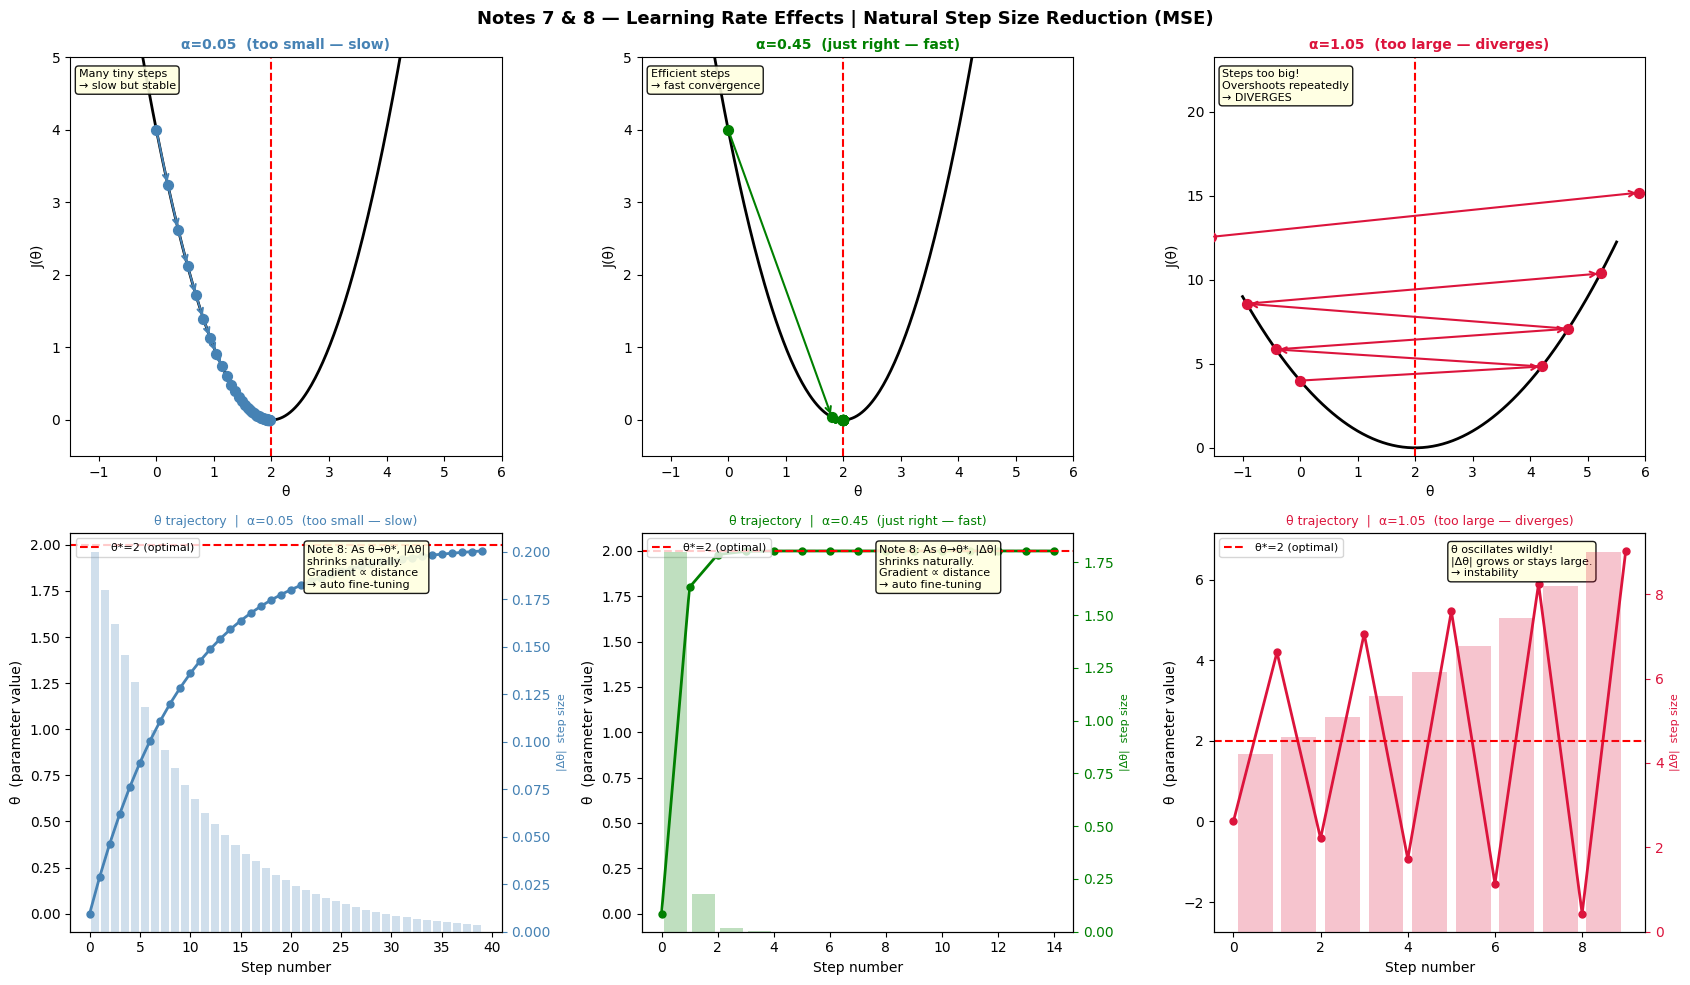

       α     final θ     final J    converged?
    0.05      2.0000      0.0000  YES
    0.45      2.0000      0.0000  YES
    1.05    101.5704   9914.2570  NO  (diverged)


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
#  Notes 7 & 8 — Learning Rate  +  Natural Step Size Reduction
#
#  Note 7: The learning rate α determines what fraction of the gradient vector
#           is applied at each parameter update step.
#
#           α too small: like an ant moving one millimeter at a time
#              → painfully slow convergence, thousands of iterations needed
#
#           α just right: steps large enough to reach the minimum in a
#              reasonable number of iterations → best case
#
#           α too large: like a person with huge strides jumping over the minimum
#              → oscillation, likely complete divergence (J grows instead of shrinks)
#
#  Note 8: In convex cost functions like MSE, as we get closer to the minimum,
#           the gradient magnitude (slope of the tangent line) naturally shrinks.
#           → Even with a fixed α, the final steps automatically get smaller
#           → A form of "automatic fine-tuning" near the minimum
# ══════════════════════════════════════════════════════════════════════════════

# ── Build a 2×3 grid of subplots ─────────────────────────────────────────────
# Top row: J(θ) curve with GD path
# Bottom row: θ trajectory over time + step sizes
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Notes 7 & 8 — Learning Rate Effects | Natural Step Size Reduction (MSE)",
             fontsize=13, fontweight="bold")

# ── Define the cost function and its gradient ─────────────────────────────────
def J(t):
    """Cost function: J(θ) = (θ-2)²  — minimum at θ*=2, J(2)=0"""
    return (t - 2) ** 2

def gJ(t):
    """Gradient of cost function: ∇J(θ) = d/dθ[(θ-2)²] = 2·(θ-2)"""
    return 2 * (t - 2)

# Horizontal axis for drawing the cost curve
theta_range = np.linspace(-1, 5.5, 300)  # 300 points from -1 to 5.5

# ── Define three learning rate scenarios ──────────────────────────────────────
# Each scenario has a different color and number of steps
scenarios = [
    {"alpha": 0.05, "label": "α=0.05  (too small — slow)",     "color": "steelblue",  "n": 40},
    {"alpha": 0.45, "label": "α=0.45  (just right — fast)",    "color": "green",      "n": 15},
    {"alpha": 1.05, "label": "α=1.05  (too large — diverges)", "color": "crimson",    "n": 10},
]

# ── Loop over three scenarios (columns 0, 1, 2) ──────────────────────────────
for col, sc in enumerate(scenarios):
    alpha   = sc["alpha"]   # learning rate for this scenario
    color   = sc["color"]   # color for this scenario
    n_steps = sc["n"]       # number of simulation steps

    # ── Simulate gradient descent trajectory ──────────────────────────────────
    # Update rule: θ_new = θ_old − α · ∇J(θ_old)
    theta_traj = [0.0]   # start at θ=0 (fixed starting point for all scenarios)

    for _ in range(n_steps - 1):
        t_new = theta_traj[-1] - alpha * gJ(theta_traj[-1])
        # theta_traj[-1]: last computed θ
        # gJ(theta_traj[-1]): gradient at current θ
        # alpha * gJ(...): step size
        theta_traj.append(t_new)

        if abs(t_new) > 20:   # emergency stop: if θ becomes very large (divergence)
            break

    theta_traj = np.array(theta_traj)        # convert list to NumPy array
    steps_arr  = np.arange(len(theta_traj))  # [0, 1, 2, ...] step indices

    # ══════════════════════════════════════════════════════════════
    #  Top row: J(θ) curve with GD steps plotted on it
    # ══════════════════════════════════════════════════════════════
    ax = axes[0, col]

    # Draw the cost function curve (the bowl)
    ax.plot(theta_range, J(theta_range), "k-", linewidth=2, label="J(θ)")

    # Plot θ positions on the curve (each dot = one GD step)
    ax.scatter(theta_traj, J(theta_traj), color=color, s=50, zorder=5)

    # Draw arrows between consecutive steps (only first 8 steps for readability)
    for i in range(min(len(theta_traj)-1, 8)):
        ax.annotate("",
                    xy    =(theta_traj[i+1], J(theta_traj[i+1])),  # arrow tip: next step
                    xytext=(theta_traj[i],   J(theta_traj[i])),    # arrow base: current step
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

    # Red vertical dashed line = minimum location (θ*=2)
    ax.axvline(2, color="red", linestyle="--", linewidth=1.5)

    # Column title with matching color
    ax.set_title(sc["label"], fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel("θ")        # x-axis: parameter
    ax.set_ylabel("J(θ)")     # y-axis: cost
    ax.set_ylim(-0.5, min(max(J(theta_traj)) + 1, 30))  # y range (capped for diverging case)
    ax.set_xlim(-1.5, 6)       # x range

    # Behavior info box
    if alpha < 0.2:
        # small α: tiny steps, slow but stable convergence
        note = "Many tiny steps\n→ slow but stable"
    elif alpha < 1.0:
        # appropriate α: balance between speed and stability
        note = "Efficient steps\n→ fast convergence"
    else:
        # large α: steps overshoot the minimum, divergence
        note = "Steps too big!\nOvershoots repeatedly\n→ DIVERGES"
    ax.text(0.02, 0.97, note, transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

    # ══════════════════════════════════════════════════════════════
    #  Bottom row: θ trajectory and step sizes over time
    # ══════════════════════════════════════════════════════════════
    ax2 = axes[1, col]

    # Plot θ value at each step
    ax2.plot(steps_arr, theta_traj, "o-", color=color, linewidth=2, markersize=5)

    # Red horizontal dashed line = optimal value θ*=2
    ax2.axhline(2, color="red", linestyle="--", linewidth=1.5, label="θ*=2 (optimal)")

    # ── Draw step sizes on a second y-axis ────────────────────────────────────
    if len(theta_traj) > 1:
        # |Δθ|: size of each step = change in θ between consecutive steps
        # np.diff: computes the difference between consecutive array elements
        step_sizes = np.abs(np.diff(theta_traj))

        # Create a second y-axis (right side) to show step sizes
        ax2_twin = ax2.twinx()  # twinx: second y-axis sharing the same x-axis

        # Draw bar chart of step sizes
        # steps_arr[:-1] + 0.5: center of each step (between step i and i+1)
        ax2_twin.bar(steps_arr[:-1] + 0.5, step_sizes,
                     alpha=0.25,   # high transparency so main plot is visible
                     color=color,
                     label="|Δθ|  (step size)")  # step size at each step

        ax2_twin.set_ylabel("|Δθ|  step size", fontsize=8, color=color)
        ax2_twin.tick_params(axis="y", colors=color)  # color ticks of second y-axis

    ax2.set_xlabel("Step number")           # x-axis: step index
    ax2.set_ylabel("θ  (parameter value)")  # y-axis: θ value
    ax2.set_title(f"θ trajectory  |  {sc['label']}", fontsize=9, color=color)
    ax2.legend(fontsize=8, loc="upper left")

    # ── Note 8 info box (natural step reduction) ──────────────────────────────
    if alpha < 0.5:
        # Note 8: in MSE, as we get closer to the minimum,
        # gradient = 2(θ-2) gets smaller → step = α·gradient also gets smaller
        note2 = ("Note 8: As θ→θ*, |Δθ|\n"
                 "shrinks naturally.\n"      # |Δθ| shrinks naturally
                 "Gradient ∝ distance\n"     # gradient is proportional to distance
                 "→ auto fine-tuning")       # → automatic fine-tuning
    elif alpha < 1.0:
        note2 = "Fast approach\nSmall final steps\n(MSE's natural\n step reduction)"
    else:
        # for large α: steps stay large or grow even larger → divergence
        note2 = "θ oscillates wildly!\n|Δθ| grows or stays large.\n→ instability"

    ax2.text(0.55, 0.97, note2, transform=ax2.transAxes, fontsize=8, va="top",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # auto-adjust spacing
plt.show()

# ── Final summary table ───────────────────────────────────────────────────────
print("=" * 65)
print(f"  {'α':>6}  {'final θ':>10}  {'final J':>10}  {'converged?':>12}")
print("=" * 65)
for sc in scenarios:
    t = 0.0  # starting point
    for _ in range(200):
        t = t - sc["alpha"] * gJ(t)  # 200 GD steps
        if abs(t) > 100:
            break  # stop if diverged
    # check convergence: is θ close enough to the minimum (θ*=2)?
    converged = "YES" if abs(t - 2) < 0.01 else "NO  (diverged)"
    print(f"  {sc['alpha']:>6.2f}  {t:>10.4f}  {J(t):>10.4f}  {converged}")


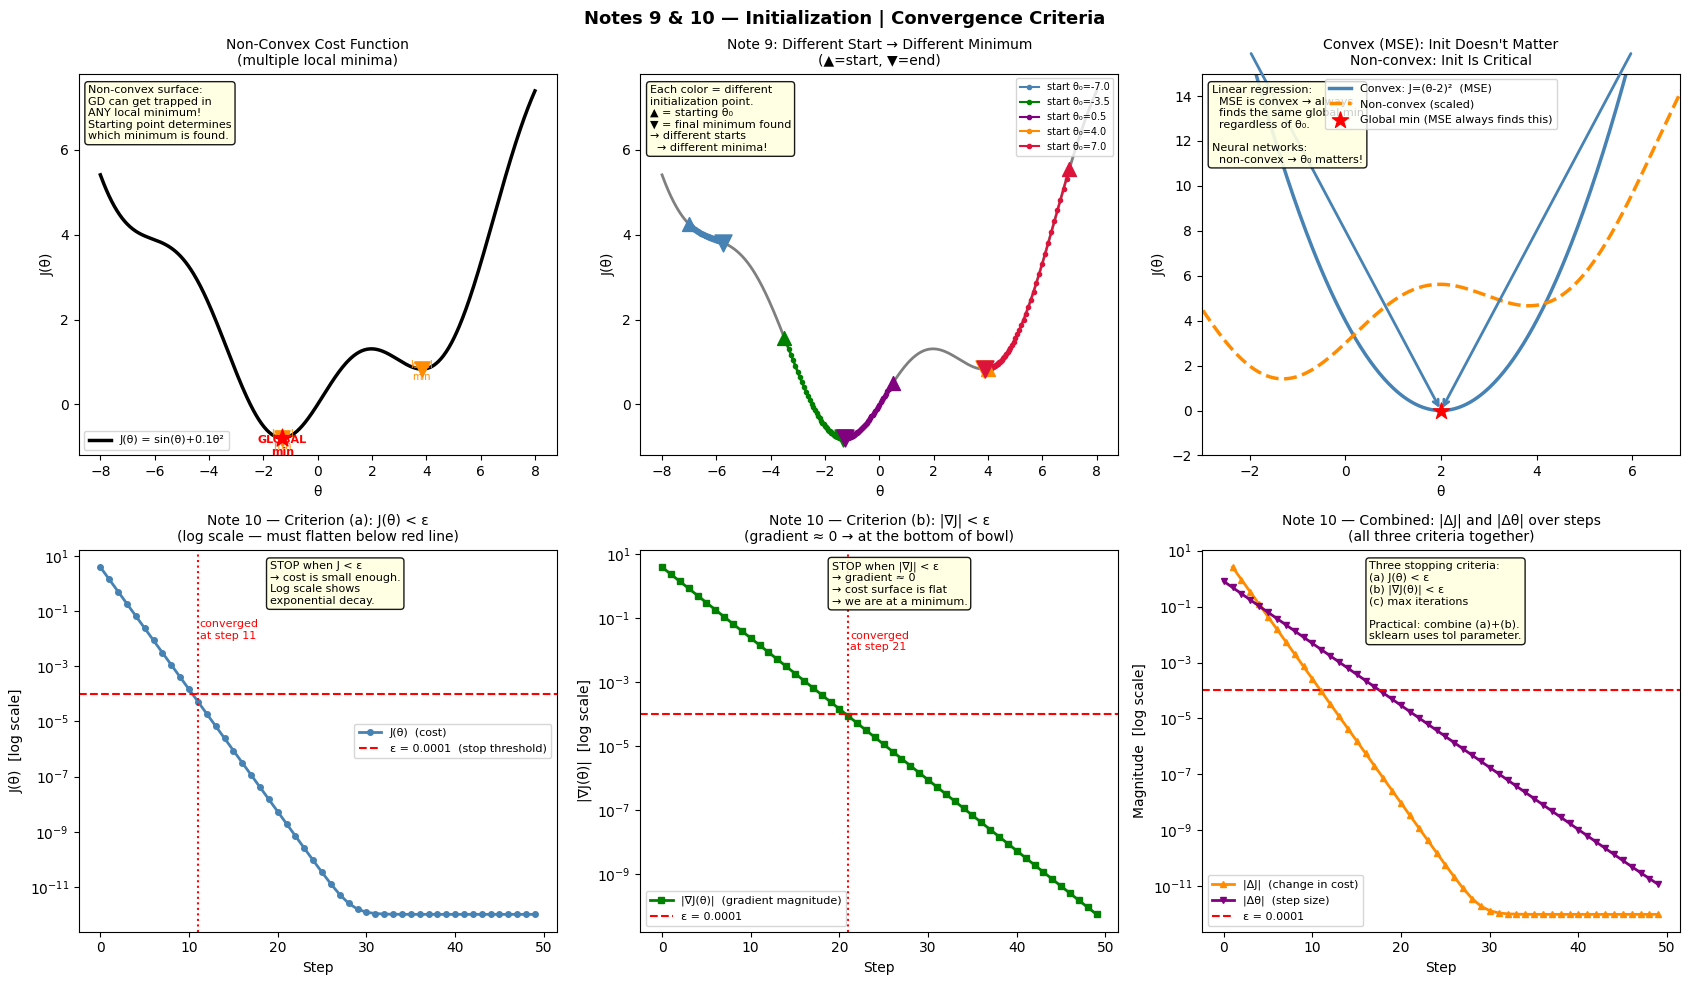

Note 9:  In convex MSE, initialization doesn't affect the result.
         In non-convex: starting point determines which local min is found.
Note 10: GD stops when J < ε, |∇J| < ε, or max iterations reached.
         sklearn uses tol= parameter for this threshold.


In [32]:
# ══════════════════════════════════════════════════════════════════════════════
#  NOTES 9 & 10 — Initialization Effect  +  Convergence Criteria
#
#  Note 9: In simple linear regression (convex MSE), the starting point θ₀
#           does not matter — gradient descent always reaches the same
#           global minimum regardless of where it starts.
#
#           However, in neural networks and non-linear regression
#           (non-convex cost surfaces):
#           The cost function has multiple local minima.
#           The starting point θ₀ determines which minimum the algorithm finds.
#           → Weight initialization is critical in neural networks.
#
#  Note 10: Gradient descent theoretically runs forever.
#            In practice, three stopping criteria are used:
#
#            (a) |J(θ)| < ε  — cost is small enough
#            (b) |∇J(θ)| < ε — gradient ≈ 0 → we are at the valley floor
#            (c) number of iterations reached max_iter
#
#            sklearn uses the tol= parameter for these thresholds.
# ══════════════════════════════════════════════════════════════════════════════

# ── required libraries ───────────────────────────────────────────────────────
from scipy.signal import argrelmin   # find local minima indices in a numeric array

# ── build a 2×3 grid of subplots ─────────────────────────────────────────────
# top row   : Note 9  — local minima + effect of starting point
# bottom row: Note 10 — convergence criteria
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Notes 9 & 10 — Initialization | Convergence Criteria",
             fontsize=13, fontweight="bold")

# ══════════════════════════════════════════════════════════════════════════════
#  NOTE 9 — Non-convex function with multiple local minima
#  J(θ) = sin(θ) + 0.1·θ²
#  This function has several hills and valleys (non-convex)
# ══════════════════════════════════════════════════════════════════════════════

# θ axis for plotting the non-convex function
theta_nc = np.linspace(-8, 8, 500)   # 500 evenly spaced points from -8 to +8

def J_nc(t):
    """Non-convex cost function: J(θ) = sin(θ) + 0.1·θ²
    sin(θ)  : creates multiple valleys (several local minima)
    0.1·θ²  : adds a gentle global curvature so one global minimum exists
    """
    return np.sin(t) + 0.1 * t**2

def gJ_nc(t):
    """Gradient of non-convex function: ∇J(θ) = d/dθ[sin(θ)+0.1θ²] = cos(θ)+0.2θ"""
    return np.cos(t) + 0.2 * t

# ── Plot 9-A (top-left): non-convex curve + mark all minima ─────────────────
ax = axes[0, 0]
ax.plot(theta_nc, J_nc(theta_nc), "k-", linewidth=2.5, label="J(θ) = sin(θ)+0.1θ²")

# find local minima numerically
# argrelmin: returns indices where each point is smaller than its neighbours
# order=20 : each point is compared against 20 neighbours on each side
local_min_idx = argrelmin(J_nc(theta_nc), order=20)[0]

# mark every local minimum with an orange downward triangle
for idx in local_min_idx:
    t_min = theta_nc[idx]     # x-coordinate of local minimum
    J_min = J_nc(t_min)       # y-coordinate (cost value) of local minimum
    ax.scatter([t_min], [J_min], color="darkorange", s=120, zorder=6, marker="v")
    ax.text(t_min, J_min - 0.25, "local\nmin", fontsize=7, ha="center", color="darkorange")

# find and mark the global minimum (lowest value over the entire range)
# np.argmin: returns the index of the smallest element in the array
global_min_t = theta_nc[np.argmin(J_nc(theta_nc))]
ax.scatter([global_min_t], [J_nc(global_min_t)], color="red", s=180, zorder=7, marker="*")
ax.text(global_min_t, J_nc(global_min_t) - 0.4, "GLOBAL\nmin",
        fontsize=8, ha="center", color="red", fontweight="bold")

ax.set_title("Non-Convex Cost Function\n(multiple local minima)", fontsize=10)
ax.set_xlabel("θ")        # x-axis: parameter value
ax.set_ylabel("J(θ)")     # y-axis: cost value
ax.legend(fontsize=8)
ax.text(0.02, 0.97,
        "Non-convex surface:\n"
        "GD can get trapped in\n"
        "ANY local minimum!\n"
        "Starting point determines\n"
        "which minimum is found.",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Plot 9-B (top-middle): GD paths from different starting points ───────────
ax = axes[0, 1]
# draw the curve with low opacity so the paths stand out
ax.plot(theta_nc, J_nc(theta_nc), "k-", linewidth=2, alpha=0.5)

# 5 different starting points, each with its own colour
start_points = [-7.0, -3.5, 0.5, 4.0, 7.0]   # spread across [-8, 8]
colors_init  = ["steelblue", "green", "purple", "darkorange", "crimson"]

alpha_init = 0.05   # small learning rate to show the full trajectory

for t0, col in zip(start_points, colors_init):
    t    = t0        # initialise θ at the starting point
    traj = [t]       # trajectory list for this starting point

    for _ in range(80):                      # at most 80 steps
        t = t - alpha_init * gJ_nc(t)        # one GD step on the non-convex function
        traj.append(t)
        if abs(gJ_nc(t)) < 1e-4:            # stopping criterion: gradient ≈ 0
            break                            # algorithm has reached a minimum

    traj = np.array(traj)

    # draw the convergence path
    ax.plot(traj, J_nc(traj), "o-", color=col, linewidth=1.5, markersize=3,
            label=f"start θ₀={t0}")

    # starting point: upward triangle ▲
    ax.scatter([t0], [J_nc(t0)], color=col, s=100, zorder=8, marker="^")

    # ending point (minimum found): downward triangle ▼
    ax.scatter([traj[-1]], [J_nc(traj[-1])], color=col, s=150, zorder=9, marker="v")

ax.set_title("Note 9: Different Start → Different Minimum\n(▲=start, ▼=end)",
             fontsize=10)
ax.set_xlabel("θ"); ax.set_ylabel("J(θ)")
ax.legend(fontsize=7, loc="upper right")
ax.text(0.02, 0.97,
        "Each color = different\n"
        "initialization point.\n"
        "▲ = starting θ₀\n"
        "▼ = final minimum found\n"
        "→ different starts\n"
        "  → different minima!",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Plot 9-C (top-right): convex MSE vs non-convex ──────────────────────────
ax = axes[0, 2]

# convex cost function (MSE)
theta_cv = np.linspace(-3, 7, 300)   # display range for MSE
def J_cv(t):
    """Convex MSE cost: J(θ) = (θ-2)²  — only one minimum at θ*=2"""
    return (t - 2)**2

# plot MSE (blue): single smooth bowl
ax.plot(theta_cv, J_cv(theta_cv), "steelblue", linewidth=2.5,
        label="Convex: J=(θ-2)²  (MSE)")

# plot non-convex function (orange dashed): multiple hills and valleys
# scaled and shifted upward so both curves are visible on the same axes
ax.plot(theta_nc, J_nc(theta_nc) * 2 + 3, "darkorange", linewidth=2.5,
        linestyle="--", label="Non-convex (scaled)")

# show two different starting points for MSE — both reach the same minimum
for t0 in [-2, 6]:    # one left of minimum, one right of minimum
    t    = float(t0)
    traj = [t]
    for _ in range(20):
        t = t - 0.3 * 2 * (t - 2)   # GD on MSE: update rule θ = θ - α·2(θ-2)
        traj.append(t)
    traj = np.array(traj)

    # draw arrow from starting point to minimum
    ax.annotate("",
                xy    =(traj[-1], J_cv(traj[-1])),   # arrow tip: minimum
                xytext=(traj[0],  J_cv(traj[0])),    # arrow base: start
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))

# mark the global minimum of MSE with a red star
ax.scatter([2], [0], color="red", s=150, zorder=8, marker="*",
           label="Global min (MSE always finds this)")

ax.set_title("Convex (MSE): Init Doesn't Matter\nNon-convex: Init Is Critical", fontsize=10)
ax.set_xlabel("θ"); ax.set_ylabel("J(θ)")
ax.legend(fontsize=8)
ax.set_xlim(-3, 7); ax.set_ylim(-2, 15)
ax.text(0.02, 0.97,
        "Linear regression:\n"
        "  MSE is convex → always\n"
        "  finds the same global min\n"
        "  regardless of θ₀.\n\n"
        "Neural networks:\n"
        "  non-convex → θ₀ matters!",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ══════════════════════════════════════════════════════════════════════════════
#  NOTE 10 — Convergence Criteria
# ══════════════════════════════════════════════════════════════════════════════

# define a simple cost function for the simulation
def J_fn(t):
    """Cost function: J(θ) = (θ-2)²  — used for Note 10 demo"""
    return (t - 2)**2

def gJ_fn(t):
    """Gradient: ∇J(θ) = 2·(θ-2)"""
    return 2 * (t - 2)

# simulation settings
alpha_conv = 0.2    # learning rate (well-chosen)
theta_conv = 0.0    # starting point
epsilon_j  = 1e-4   # threshold for criterion (a): J < ε
epsilon_g  = 1e-4   # threshold for criterion (b): |∇J| < ε
max_iter   = 50     # criterion (c): maximum number of iterations

# dictionary to record every variable at every step
history = {
    "step"        : [],   # step index
    "theta"       : [],   # current θ value
    "J"           : [],   # cost at current θ
    "grad"        : [],   # gradient magnitude |∇J|
    "delta_J"     : [],   # change in cost relative to previous step |ΔJ|
    "delta_theta" : [],   # step size |Δθ| = α·|∇J|
}

J_prev = J_fn(theta_conv)   # cost from previous step (needed to compute |ΔJ|)

# ── main simulation loop ──────────────────────────────────────────────────────
for i in range(max_iter):
    g       = gJ_fn(theta_conv)          # gradient at current θ
    J_cur   = J_fn(theta_conv)           # cost at current θ
    delta_J = abs(J_cur - J_prev)        # |ΔJ| = |current cost − previous cost|

    # record values for this step
    history["step"].append(i)
    history["theta"].append(theta_conv)
    history["J"].append(J_cur)
    history["grad"].append(abs(g))                                        # |∇J|
    history["delta_J"].append(delta_J if i > 0 else float("nan"))        # no ΔJ on step 0
    history["delta_theta"].append(abs(alpha_conv * g))                   # |Δθ| = α·|∇J|

    J_prev     = J_cur                            # save cost for next iteration
    theta_conv = theta_conv - alpha_conv * g      # update rule: θ_new = θ - α·∇J

# convert lists to NumPy arrays for plotting
steps  = np.array(history["step"])
J_arr  = np.array(history["J"])           # cost history
g_arr  = np.array(history["grad"])        # |∇J| history
dJ_arr = np.array(history["delta_J"])     # |ΔJ| history

# ── Plot 10-A (bottom-left): J(θ) over steps ─────────────────────────────────
ax = axes[1, 0]

# semilogy: logarithmic y-axis — makes both large and tiny values visible
# + 1e-12: prevents log(0) which is undefined
ax.semilogy(steps, J_arr + 1e-12, "steelblue", linewidth=2, marker="o", markersize=4,
            label="J(θ)  (cost)")

# red dashed horizontal line = stopping threshold ε
ax.axhline(epsilon_j, color="red", linestyle="--", linewidth=1.5,
           label=f"ε = {epsilon_j}  (stop threshold)")

# find the first step where J drops below ε
# next(..., None): returns None if no step satisfies the condition
conv_step_J = next((i for i, j in enumerate(J_arr) if j < epsilon_j), None)
if conv_step_J:
    ax.axvline(conv_step_J, color="red", linestyle=":", linewidth=1.5)   # mark convergence step
    ax.text(conv_step_J + 0.2, 1e-2, f"converged\nat step {conv_step_J}", fontsize=8, color="red")

ax.set_title("Note 10 — Criterion (a): J(θ) < ε\n(log scale — must flatten below red line)",
             fontsize=10)
ax.set_xlabel("Step")
ax.set_ylabel("J(θ)  [log scale]")
ax.legend(fontsize=8)
ax.text(0.4, 0.97,
        "STOP when J < ε\n"
        "→ cost is small enough.\n"
        "Log scale shows\n"
        "exponential decay.",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Plot 10-B (bottom-middle): |∇J| over steps ───────────────────────────────
ax = axes[1, 1]

# plot gradient magnitude with logarithmic y-axis
ax.semilogy(steps, g_arr + 1e-12, "green", linewidth=2, marker="s", markersize=4,
            label="|∇J(θ)|  (gradient magnitude)")
ax.axhline(epsilon_g, color="red", linestyle="--", linewidth=1.5, label=f"ε = {epsilon_g}")

# find convergence step based on criterion |∇J| < ε
conv_step_g = next((i for i, g in enumerate(g_arr) if g < epsilon_g), None)
if conv_step_g:
    ax.axvline(conv_step_g, color="red", linestyle=":", linewidth=1.5)
    ax.text(conv_step_g + 0.2, 1e-2, f"converged\nat step {conv_step_g}", fontsize=8, color="red")

ax.set_title("Note 10 — Criterion (b): |∇J| < ε\n(gradient ≈ 0 → at the bottom of bowl)",
             fontsize=10)
ax.set_xlabel("Step")
ax.set_ylabel("|∇J(θ)|  [log scale]")
ax.legend(fontsize=8)
ax.text(0.4, 0.97,
        "STOP when |∇J| < ε\n"
        "→ gradient ≈ 0\n"
        "→ cost surface is flat\n"
        "→ we are at a minimum.",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Plot 10-C (bottom-right): |ΔJ| and |Δθ| together ────────────────────────
ax = axes[1, 2]

delta_theta_arr = np.array(history["delta_theta"])   # step size array
valid = ~np.isnan(dJ_arr)   # boolean mask to exclude NaN (step 0 has no ΔJ)
# ~        : logical NOT
# np.isnan : True where value is NaN

# plot |ΔJ| (change in cost) with orange upward triangles
ax.semilogy(steps[valid], dJ_arr[valid] + 1e-12, "darkorange", linewidth=2,
            marker="^", markersize=4, label="|ΔJ|  (change in cost)")

# plot |Δθ| (step size) with purple downward triangles
ax.semilogy(steps, delta_theta_arr + 1e-12, "purple", linewidth=2,
            marker="v", markersize=4, label="|Δθ|  (step size)")

# stopping threshold line
ax.axhline(epsilon_j, color="red", linestyle="--", linewidth=1.5, label=f"ε = {epsilon_j}")

ax.set_title("Note 10 — Combined: |ΔJ| and |Δθ| over steps\n(all three criteria together)",
             fontsize=10)
ax.set_xlabel("Step")
ax.set_ylabel("Magnitude  [log scale]")
ax.legend(fontsize=8)
ax.text(0.35, 0.97,
        "Three stopping criteria:\n"
        "(a) J(θ) < ε\n"
        "(b) |∇J(θ)| < ε\n"
        "(c) max iterations\n\n"
        "Practical: combine (a)+(b).\n"
        "sklearn uses tol parameter.",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()   # automatically adjust spacing between subplots
plt.show()

# ── summary printout ──────────────────────────────────────────────────────────
print("Note 9:  In convex MSE, initialization doesn't affect the result.")
print("         In non-convex: starting point determines which local min is found.")
print("Note 10: GD stops when J < ε, |∇J| < ε, or max iterations reached.")
print("         sklearn uses tol= parameter for this threshold.")
